In [1]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [2]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0


,TIME_NS,TIME_S,TIME_ABS,EVENT,MCRUN,TEL_ID,num_tel,HG,LG,TTP
0,1030456,0,1030456,3519,263210,9,2,"[[2126, 2121, 2134, 2208, 2194, 2174, 2226, 22...","[[2128, 2128, 2129, 2132, 2132, 2130, 2133, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
1,3274338,0,3274338,3803,263210,9,1,"[[2110, 2200, 2063, 2231, 2197, 2243, 2190, 20...","[[2127, 2132, 2125, 2133, 2132, 2134, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
2,3679960,0,3679960,3805,263210,9,8,"[[2109, 2063, 2115, 2171, 2186, 2107, 2261, 22...","[[2127, 2125, 2128, 2130, 2131, 2127, 2134, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3,6391145,0,6391145,1011,263211,9,1,"[[2085, 2210, 2268, 2181, 2261, 2070, 2185, 21...","[[2126, 2132, 2135, 2131, 2135, 2125, 2131, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
4,10916501,0,10916501,1209,263211,9,1,"[[2126, 2191, 2261, 2007, 2195, 2182, 2129, 22...","[[2128, 2131, 2135, 2122, 2131, 2131, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 123,..."
...,...,...,...,...,...,...,...,...,...,...
3157,316424396,9,9316424396,7915,266398,9,8,"[[2152, 2187, 2166, 2148, 2147, 2127, 2174, 21...","[[2129, 2131, 2130, 2129, 2129, 2128, 2130, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."
3158,321000985,9,9321000985,8402,266398,9,9,"[[2113, 2050, 2263, 2073, 2132, 2078, 2293, 20...","[[2127, 2124, 2135, 2125, 2128, 2126, 2136, 21...","[[255, 255, 255, 158, 255, 255, 255, 255, 255,..."
3159,326043880,9,9326043880,1403,266399,9,9,"[[2385, 2234, 2198, 2229, 2154, 2125, 2167, 21...","[[2141, 2133, 2132, 2133, 2129, 2128, 2130, 21...","[[117, 255, 255, 255, 255, 255, 255, 255, 255,..."
3160,329345615,9,9329345615,2419,266399,9,6,"[[2147, 2090, 2225, 2220, 2201, 2126, 2132, 22...","[[2129, 2126, 2133, 2133, 2132, 2128, 2128, 21...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,..."


In [71]:
def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]

print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


4213


In [72]:
# ======================= FUNZIONI GEOMETRICHE =======================

def intersection(p1, d1, p2, d2, eps_ang=1e-1, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])
def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])


In [ ]:
# ======================= CALCOLO INTERSEZIONI =======================
inters_hg = []
inters_lg = []
dfR = pd.DataFrame(results)
for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            P = intersection(rette_hg[i]["p0"], d1,rette_hg[j]["p0"], d2)

            if P is None:
                continue

            inters_hg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_lg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)


In [87]:
from sklearn.cluster import DBSCAN

epsilon = 350
min_samples = 1
revent_map = {}
revent_counter = 0
# ======================= HG =======================
dist_hg = []
delta_hg = []

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):
    # -------- REVENT --------
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    # ------------------------

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "HG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        # ---------- pesi angolari (VETTORIALI) ----------
        pairs = np.array(dfP["pair"].tolist())      # (N,2)
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]
        
        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2   # sin^2(theta)
        pairs = np.array(dfP["pair"].tolist())      # (N,2)
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        det = d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0]

        mask = np.abs(det) >= 1e-1    # TAGLIO NUMERICO

        if not np.any(mask):
            continue

        w   = det[mask]**2
        Pcl = Pcl[mask]
        # ---------- stimatori ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        # ---------- diagnostica ----------
        delta_hg.append(np.linalg.norm(P_weight - P_simple))

        # ---------- distanze ----------
        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_hg.append({
                "revent": revent, 
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })
                

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []
delta_lg = []

for (event, mcrun), df_evt in df_int_lg.groupby(["event", "mcrun"]):
    # -------- REVENT --------
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    # ------------------------
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "LG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        pairs = np.array(dfP["pair"].tolist())
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        delta_lg.append(np.linalg.norm(P_weight - P_simple))

        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_lg.append({
                "revent": revent,
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })

df_dist_lg = pd.DataFrame(dist_lg)


In [74]:
#=========================== FAKE EVENT ==================================
import random
#vediamo due eventi presi casualmente
groups = list(df_all_sorted.groupby(["EVENT", "MCRUN"]))
random.shuffle(groups)
groups_A = groups[:len(groups)//2]
groups_B = groups[len(groups)//2:len(groups)]
fake_events = []
fevent_counter = 0
for i, ((evtA, dfA), (evtB, dfB)) in enumerate(zip(groups_A, groups_B)):
    if len(dfA) < 3 or len(dfB) < 3:
        continue

    #prendi almeno 3 telescopi da A e non più di quelli disponibili
    nA = max(3, len(dfA) // 2)
    nA = min(nA, len(dfA))
    partA = dfA.sample(n=nA, replace=False)

    #prendi almeno 3 telescopi da B e non più di quelli disponibili
    nB = max(3, len(dfB) // 2)
    nB = min(nB, len(dfB))
    partB = dfB.sample(n=nB, replace=False)

    # unione -> evento fittizio
    df_fake = pd.concat([partA, partB], ignore_index=True)
  
  
    # etichetta evento fittizio con contatore progressivo
    df_fake["FAKE_EVENT"] = fevent_counter
    fevent_counter += 1
    
    fake_events.append(df_fake)
#dataframe con tutti eventi fittizi
df_fake_all = pd.concat(fake_events, ignore_index=True)
df_fake_all.columns
df_fake_all[['FAKE_EVENT', 'EVENT', 'MCRUN']].head(20)

,FAKE_EVENT,EVENT,MCRUN
0,0,7203,263716
1,0,7203,263716
2,0,7203,263716
3,0,5817,263661
4,0,5817,263661
5,0,5817,263661
6,1,9711,266312
7,1,9711,266312
8,1,9711,266312
9,1,9711,266312


In [118]:
#########ora stessa analisi di sopra

taglio=0.1

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results_f = []
for fevent, df_evt in df_fake_all.groupby(["FAKE_EVENT"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results_f.append({
            "event": row["EVENT"],       
            "mcrun": row["MCRUN"],  
            "fevent": int(fevent[0]),   
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })
dfR_f = pd.DataFrame(results_f)
# ======================= CALCOLO INTERSEZIONI =======================
inters_hg_f = []
inters_lg_f = []

  # results_f deve avere 'event', 'mcrun', 'fevent', 'HG', 'LG'

for fevent, df_evt in dfR_f.groupby("fevent"):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values
    events = df_evt["event"].values       # array degli eventi originali
    mcruns = df_evt["mcrun"].values       # array dei mcrun originali

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            # ignora se stesso telescopio
            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]
            ###########################################################################################verificare sto sen(theta)
            # ignora rette quasi parallele ########################################################################################################
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < taglio:
                continue

            # ignora se stesso evento reale
            #if (df_evt.iloc[i]["event"] == df_evt.iloc[j]["event"]) and (df_evt.iloc[i]["mcrun"] == df_evt.iloc[j]["mcrun"]):
                #continue

            #evt_i = (df_evt.iloc[i]["mcrun"], df_evt.iloc[i]["event"])
            #evt_j = (df_evt.iloc[j]["mcrun"], df_evt.iloc[j]["event"])
            #if evt_i >= evt_j:
                #continue
            P = intersection(rette_hg[i]["p0"], d1, rette_hg[j]["p0"], d2)
            if P is None:
                continue

            inters_hg_f.append({
                "fevent": fevent,
                "P": P,
                "pair": (i, j),
                "d1": d1,
                "d2": d2,
                #"p01":rette_hg[i]["p0"],
                #"p02":rette_hg[j]["p0"],
                "event_i": events[i],   # evento originale della retta i
                "mcrun_i": mcruns[i],   # mcrun originale della retta i
                "event_j": events[j],   # evento originale della retta j
                "mcrun_j": mcruns[j],   # mcrun originale della retta j
                "tel_i": rette_hg[i]["tel"],
                "tel_j": rette_hg[j]["tel"]
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            # ignora se stesso telescopio
            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            # ignora rette quasi parallele
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < taglio:
                continue
             # ignora se stesso evento reale
            #if (df_evt.iloc[i]["event"] == df_evt.iloc[j]["event"]) and (df_evt.iloc[i]["mcrun"] == df_evt.iloc[j]["mcrun"]):
                #continue

            P = intersection(rette_lg[i]["p0"], d1, rette_lg[j]["p0"], d2)
            if P is None:
                continue
            # per i fevent
            
            inters_lg_f.append({
                "fevent": fevent,
                "P": P,
                "pair": (i, j),
                "d1": d1,
                "d2": d2,
                #"p01":rette_lg[i]["p0"],
                #"p02":rette_lg[j]["p0"],
                "event_i": events[i],
                "mcrun_i": mcruns[i],
                "event_j": events[j],
                "mcrun_j": mcruns[j],
                "tel_i": rette_lg[i]["tel"],
                "tel_j": rette_lg[j]["tel"]
            })

# dataframe finali
df_int_hg_f = pd.DataFrame(inters_hg_f)
df_int_lg_f = pd.DataFrame(inters_lg_f)

#print(df_int_hg_f[["fevent","mcrun_j","event_j","d1"]].head(40))
#print(dfR_f["fevent"].head(10))
print(df_int_hg_f.columns)
# numero di punti per fevent
n_points_per_fevent = df_int_hg_f.groupby("fevent").size().reset_index(name="n_points")

# mostra il risultato
print(n_points_per_fevent)


Index(['fevent', 'P', 'pair', 'd1', 'd2', 'event_i', 'mcrun_i', 'event_j',
       'mcrun_j', 'tel_i', 'tel_j'],
      dtype='object')
     fevent  n_points
0         0        13
1         1        24
2         2         8
3         3        16
4         4        21
..      ...       ...
205     205        17
206     206        12
207     207        13
208     208        17
209     209        16

[210 rows x 2 columns]


In [119]:
##### debug
for fevent, df_evt in dfR_f.groupby("fevent"):
    print(f"fevent {fevent} ha {len(df_evt)} rette, telescopi: {df_evt['HG'].apply(lambda r: r['tel']).tolist()}")


fevent 0 ha 6 rette, telescopi: [9, 5, 7, 8, 5, 7]
fevent 1 ha 8 rette, telescopi: [1, 9, 4, 6, 4, 2, 1, 3]
fevent 2 ha 6 rette, telescopi: [7, 9, 8, 5, 9, 8]
fevent 3 ha 7 rette, telescopi: [5, 7, 4, 3, 7, 8, 5]
fevent 4 ha 8 rette, telescopi: [9, 2, 3, 5, 5, 4, 7, 6]
fevent 5 ha 7 rette, telescopi: [4, 8, 9, 5, 3, 2, 5]
fevent 6 ha 6 rette, telescopi: [6, 7, 4, 2, 1, 6]
fevent 7 ha 7 rette, telescopi: [9, 8, 5, 4, 5, 9, 2]
fevent 8 ha 6 rette, telescopi: [8, 2, 6, 8, 2, 5]
fevent 9 ha 7 rette, telescopi: [5, 1, 4, 8, 6, 2, 4]
fevent 10 ha 7 rette, telescopi: [7, 2, 6, 4, 2, 4, 3]
fevent 11 ha 7 rette, telescopi: [5, 7, 2, 6, 3, 6, 2]
fevent 12 ha 8 rette, telescopi: [3, 7, 6, 9, 4, 6, 3, 7]
fevent 13 ha 7 rette, telescopi: [9, 5, 4, 6, 9, 8, 5]
fevent 14 ha 7 rette, telescopi: [2, 3, 1, 7, 9, 2, 4]
fevent 15 ha 7 rette, telescopi: [9, 5, 7, 5, 2, 9, 4]
fevent 16 ha 7 rette, telescopi: [2, 5, 8, 4, 9, 6, 8]
fevent 17 ha 8 rette, telescopi: [4, 3, 6, 1, 7, 1, 6, 3]
fevent 18 ha 6 rette

In [120]:
theta1 = 0
theta2 = np.pi

d1 = (np.sin(theta1), np.cos(theta1))
d2 = (np.sin(theta2), np.cos(theta2))

print((d1[0]*d2[1] - d1[1]*d2[0])**2)
####################### CAPIRE IL TAGLIO #################################à
print("taglio applicato ", taglio,"corrispondente a ", np.degrees(np.arcsin(taglio)))

print(" prima taglio applicato ", 0.001,"corrispondente a ", np.degrees(np.arcsin(0.001)))


1.4997597826618576e-32
taglio applicato  0.1 corrispondente a  5.739170477266787
 prima taglio applicato  0.001 corrispondente a  0.0572957890623832


In [121]:

epsilon = 350
min_samples = 1

# ======================= HG =======================
dist_hg_f = []

for fevent, df_evt in df_int_hg_f.groupby("fevent"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    # clustering DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # rette dell'evento falso
    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "HG"]   
    p0  = np.vstack([r["p0"] for r in dfR_evt])
    d   = np.vstack([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    events = dfR_f.loc[dfR_f["fevent"] == fevent, "event"].values
    mcruns = dfR_f.loc[dfR_f["fevent"] == fevent, "mcrun"].values

    # ciclo cluster
    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # ---------- calcolo pesi angolari ----------
        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)   # sin^2(theta)

        w = np.array(w)

        # ---------- media pesata e semplice ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)
        evt_arr = dfR_f.loc[dfR_f["fevent"] == fevent, "event"].values
        mc_arr  = dfR_f.loc[dfR_f["fevent"] == fevent, "mcrun"].values
        for t, dm_s, dm_w, dmed, evt, mc in zip(
            tel, dist_mean_simple, dist_mean_weighted, dist_median,evt_arr,mc_arr):
            dist_hg_f.append({
                "fevent": fevent,
                "event" : evt,
                "mcrun": mc,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_weight": dm_w,
                "d_median": dmed
            })

df_dist_hg_f = pd.DataFrame(dist_hg_f)


# ======================= LG =======================
dist_lg_f = []

for fevent, df_evt in df_int_lg_f.groupby("fevent"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "LG"]   
    p0  = np.vstack([r["p0"] for r in dfR_evt])
    d   = np.vstack([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    events = dfR_f.loc[dfR_f["fevent"] == fevent, "event"].values
    mcruns = dfR_f.loc[dfR_f["fevent"] == fevent, "mcrun"].values

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)

        w = np.array(w)

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)
        evt_arr = dfR_f.loc[dfR_f["fevent"] == fevent, "event"].values
        mc_arr  = dfR_f.loc[dfR_f["fevent"] == fevent, "mcrun"].values
        for t, dm_s, dm_w, dmed, evt, mc in zip(
            tel, dist_mean_simple, dist_mean_weighted, dist_median,evt_arr,mc_arr):
            dist_lg_f.append({
                "fevent": fevent,
                "event" : evt,
                "mcrun": mc,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_weight": dm_w,
                "d_median": dmed
            })

df_dist_lg_f = pd.DataFrame(dist_lg_f)
#print(df_dist_hg_f)
#df_dist_hg_f[["fevent","event","mcrun","tel","cluster"]].head(20)
df_dist_hg_f.columns


Index(['fevent', 'event', 'mcrun', 'cluster', 'tel', 'P_simple', 'P_weight',
       'P_median', 'd_mean_simple', 'd_weight', 'd_median'],
      dtype='object')

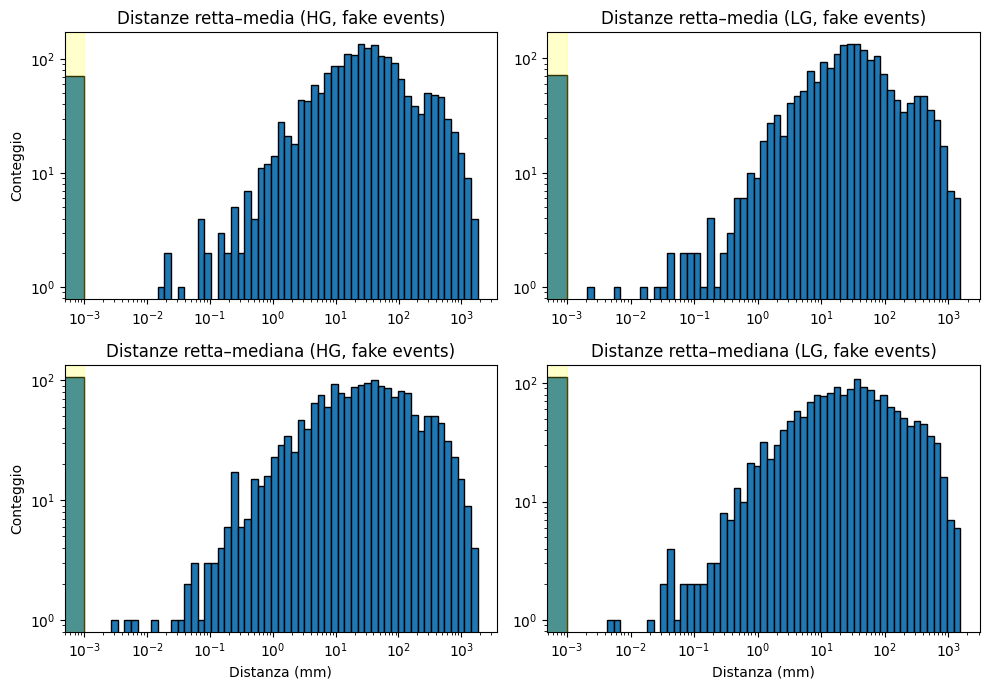

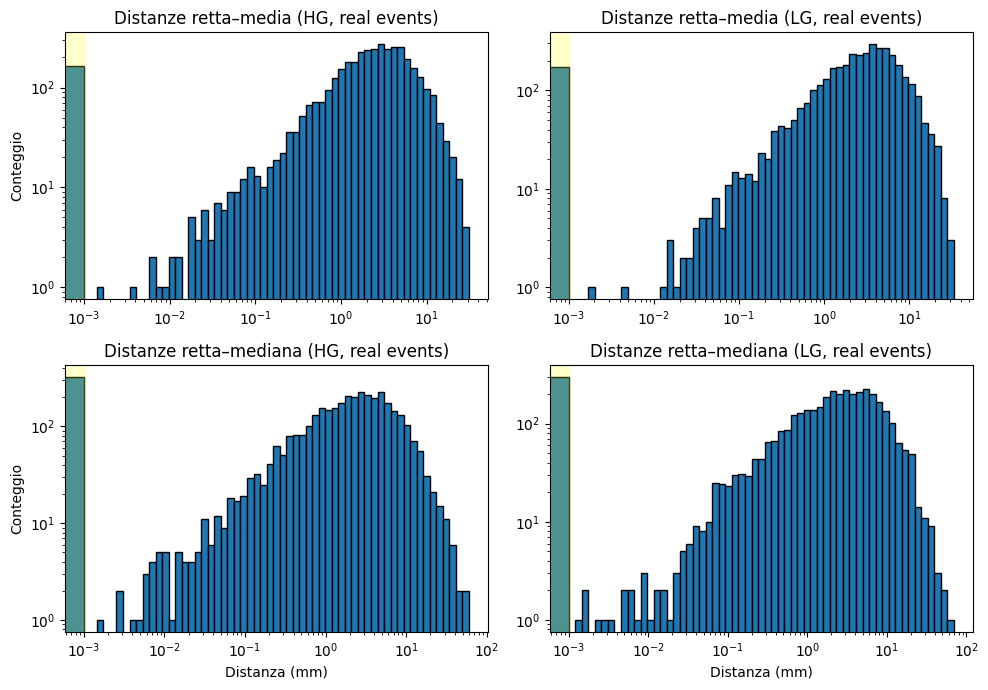

In [122]:
# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg_f   = df_dist_hg_f["d_weight"].values
d_median_hg_f = df_dist_hg_f["d_median"].values
d_mean_lg_f  = df_dist_lg_f["d_weight"].values
d_median_lg_f = df_dist_lg_f["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg_f   = d_mean_hg_f[np.isfinite(d_mean_hg_f) & (d_mean_hg_f > 0)]
d_median_hg_f = d_median_hg_f[np.isfinite(d_median_hg_f) & (d_median_hg_f > 0)]
d_mean_lg_f   = d_mean_lg_f[np.isfinite(d_mean_lg_f) & (d_mean_lg_f > 0)]
d_median_lg_f = d_median_lg_f[np.isfinite(d_median_lg_f) & (d_median_lg_f > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=60, zero_threshold=0.001):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg_f)
bins_median_hg = smart_bins(d_median_hg_f)
bins_mean_lg   = smart_bins(d_mean_lg_f)
bins_median_lg = smart_bins(d_median_lg_f)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg_f, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, fake events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg_f, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, fake events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg_f, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, fake events)")

axes[1,1].hist(d_median_lg_f, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, fake events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.axvspan(0, 0.001, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()
# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg  = df_dist_lg["d_weight"].values
d_median_lg = df_dist_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=60, zero_threshold=0.001):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg)
bins_median_hg = smart_bins(d_median_hg)
bins_mean_lg   = smart_bins(d_mean_lg)
bins_median_lg = smart_bins(d_median_lg)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, real events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, real events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, real events)")

axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, real events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.axvspan(0, 0.001, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


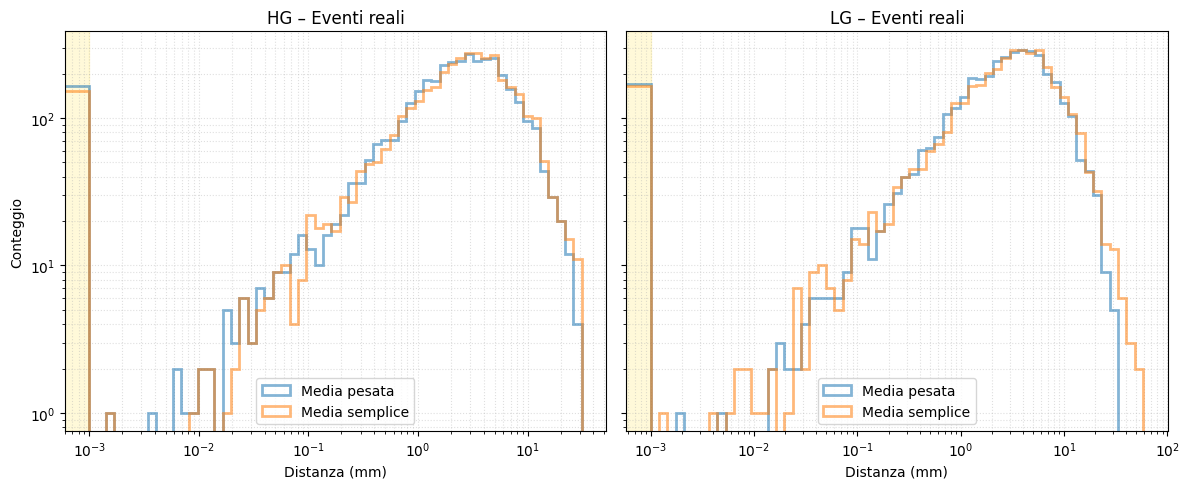

In [123]:
#CONFRONTO MEDIA PESATA E MEDIA SEMPLICE
# 
#  ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_simple_hg = df_dist_hg["d_simple"].values
d_mean_lg  = df_dist_lg["d_weight"].values
d_simple_lg = df_dist_lg["d_simple"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_simple_hg = d_simple_hg[np.isfinite(d_simple_hg) & (d_simple_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_simple_lg = d_simple_lg[np.isfinite(d_simple_lg) & (d_simple_lg > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=60, zero_threshold=0.001):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg)
#bins_simple_hg = smart_bins(d_simple_hg)
#bins_mean_lg   = smart_bins(d_mean_lg)
bins_simple_lg = smart_bins(d_simple_lg)

# ===================== PLOT =====================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# -------------------- HG --------------------
axes[0].hist(d_mean_hg,bins=bins_mean_hg,alpha=0.55,color="tab:blue",label="Media pesata",histtype="step",linewidth=2)
axes[0].hist(d_simple_hg,bins=bins_mean_hg,alpha=0.55,color="tab:orange",label="Media semplice",histtype="step",linewidth=2)

axes[0].set_title("HG – Eventi reali")
axes[0].set_xlabel("Distanza (mm)")
axes[0].set_ylabel("Conteggio")
axes[0].legend()

# -------------------- LG --------------------
axes[1].hist(d_mean_lg,bins=bins_simple_lg,alpha=0.55,color="tab:blue",label="Media pesata",histtype="step",linewidth=2)
axes[1].hist(d_simple_lg,bins=bins_simple_lg,alpha=0.55,color="tab:orange",label="Media semplice",histtype="step",linewidth=2)

axes[1].set_title("LG – Eventi reali")
axes[1].set_xlabel("Distanza (mm)")
axes[1].legend()

# -------------------- Scala log + banda --------------------
for ax in axes:
    ax.axvspan(0, 1e-3, color="gold", alpha=0.15)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", ls=":", alpha=0.4)

plt.tight_layout()
plt.show()




DIAGNOSTICA fevent 8

1) RETTE:
   Numero rette: 6
   Tel 8: HG p0=[-85.76412477  35.33080489], event=8402, mcrun=266228
   Tel 2: HG p0=[-133.72461564   54.82547201], event=8402, mcrun=266228
   Tel 6: HG p0=[-111.51750719   39.55804335], event=8402, mcrun=266228
   Tel 8: HG p0=[159.65443034 -23.68567106], event=5817, mcrun=263420
   Tel 2: HG p0=[105.9744141   -9.90119704], event=5817, mcrun=263420
   Tel 5: HG p0=[132.04043392 -18.49267729], event=5817, mcrun=263420

2) INTERSEZIONI:
   Numero intersezioni: 13
                                             P  event_i  mcrun_i  event_j  \
128   [-103.4064908053407, 124.32768287619552]     8402   266228     8402   
129   [-111.2043698512016, 163.66406715122918]     8402   266228     8402   
130   [-59.71230283753474, -96.08755546986293]     8402   266228     5817   
131  [-34.134744630992934, -225.1134934861264]     8402   266228     5817   
132   [-111.34956500282293, 106.1187329217604]     8402   266228     8402   

     mcrun_j  
1

/tmp/ipykernel_281131/2678182853.py:111: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


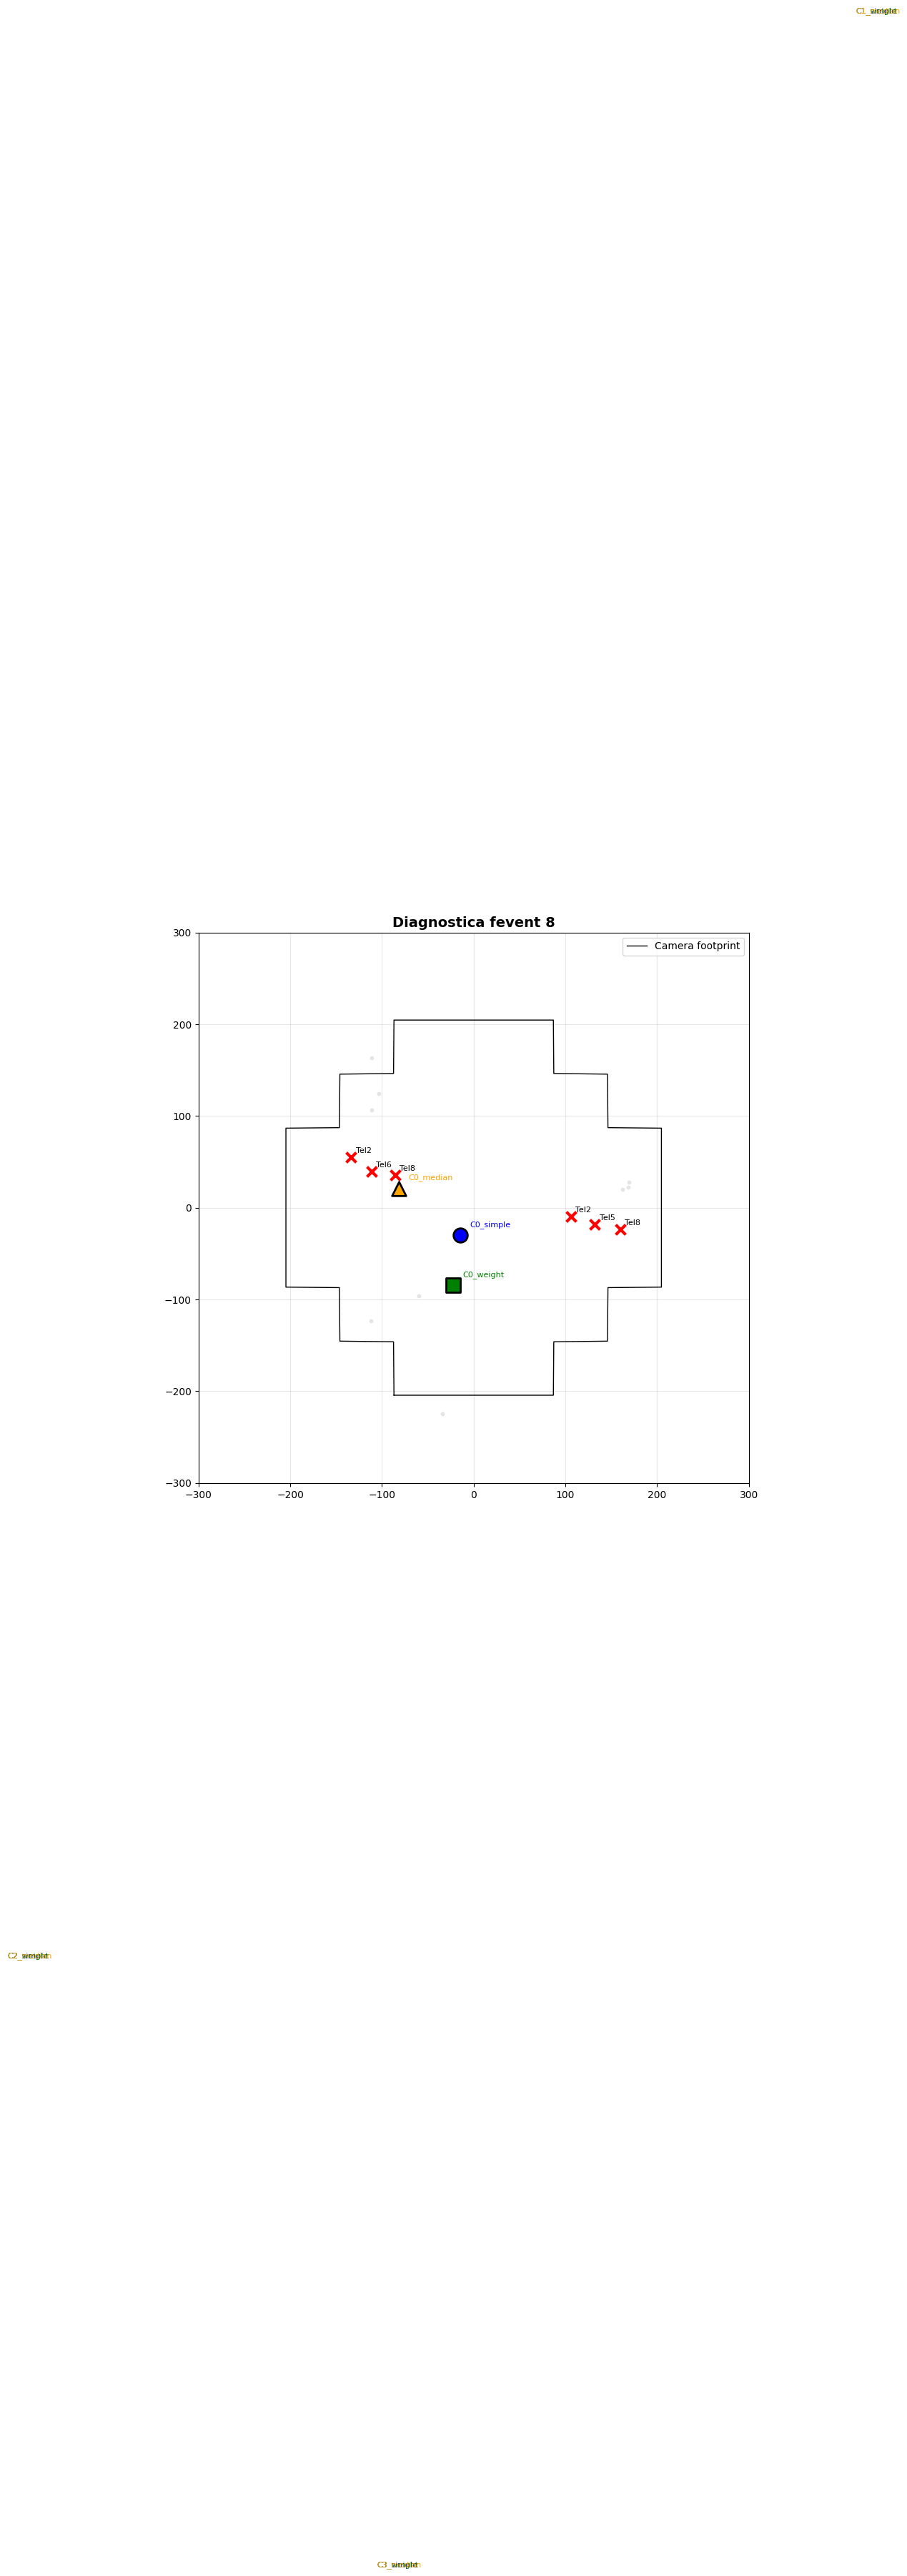

In [124]:
# ==================== DIAGNOSTICA ====================

# Prendi un fevent specifico
fevent_test = fevents_big_hg[0]
print(f"\n{'='*70}")
print(f"DIAGNOSTICA fevent {fevent_test}")
print(f"{'='*70}")

# 1) Controlla le rette
print(f"\n1) RETTE:")
rette_test = [r for r in results_f if r["fevent"] == fevent_test]
print(f"   Numero rette: {len(rette_test)}")
for r in rette_test:
    print(f"   Tel {r['HG']['tel']}: HG p0={r['HG']['p0']}, event={r['event']}, mcrun={r['mcrun']}")

# 2) Controlla le intersezioni
print(f"\n2) INTERSEZIONI:")
inters_test_hg = df_int_hg_f[df_int_hg_f["fevent"] == fevent_test]
print(f"   Numero intersezioni: {len(inters_test_hg)}")
print(inters_test_hg[["P", "event_i", "mcrun_i", "event_j", "mcrun_j"]].head())

# Stampa coordinate delle prime 5 intersezioni
print(f"\n   Prime 5 intersezioni (coordinate):")
for i, P in enumerate(inters_test_hg["P"].values[:5]):
    print(f"   P[{i}] = {P}")

# 3) Controlla i cluster
print(f"\n3) CLUSTER:")
df_test = df_dist_hg_f[df_dist_hg_f["fevent"] == fevent_test]
print(f"   Numero righe in df_dist: {len(df_test)}")
print(f"   Cluster unici: {df_test['cluster'].unique()}")

for cluster_id in df_test["cluster"].unique():
    print(f"\n   Cluster {cluster_id}:")
    df_cl = df_test[df_test["cluster"] == cluster_id]
    
    # Prendi la prima riga
    row = df_cl.iloc[0]
    print(f"      P_simple = {row['P_simple']}")
    print(f"      P_weight = {row['P_weight']}")
    print(f"      P_median = {row['P_median']}")
    
    # Controlla se tutti hanno gli stessi P
    print(f"      Verifica coerenza:")
    for idx, r in df_cl.iterrows():
        if not np.allclose(r['P_simple'], row['P_simple']):
            print(f"      ⚠️ P_simple diverso alla riga {idx}!")
        if not np.allclose(r['P_weight'], row['P_weight']):
            print(f"      ⚠️ P_weight diverso alla riga {idx}!")
        if not np.allclose(r['P_median'], row['P_median']):
            print(f"      ⚠️ P_median diverso alla riga {idx}!")
    
    # Controlla le distanze
    print(f"      Distanze d_weight:")
    print(f"         {df_cl['d_weight'].values}")

# 4) Controlla i limiti del plot
print(f"\n4) LIMITI GEOMETRICI:")
all_P = np.vstack(inters_test_hg["P"].values)
print(f"   X range intersezioni: [{all_P[:, 0].min():.2f}, {all_P[:, 0].max():.2f}]")
print(f"   Y range intersezioni: [{all_P[:, 1].min():.2f}, {all_P[:, 1].max():.2f}]")

all_p0_hg = np.array([r["HG"]["p0"] for r in rette_test])
print(f"   X range centroidi HG: [{all_p0_hg[:, 0].min():.2f}, {all_p0_hg[:, 0].max():.2f}]")
print(f"   Y range centroidi HG: [{all_p0_hg[:, 1].min():.2f}, {all_p0_hg[:, 1].max():.2f}]")

# 5) Plot diagnostico semplificato
fig, ax = plt.subplots(figsize=(10, 10))

# Footprint
ax.plot(xfp, yfp, 'k-', linewidth=1, label='Camera footprint')

# Tutte le intersezioni (piccole)
for P in inters_test_hg["P"].values:
    ax.scatter(P[0], P[1], s=10, color="lightgray", alpha=0.5, zorder=1)

# Centroidi HG (rette)
for r in rette_test:
    p0 = r["HG"]["p0"]
    ax.scatter(p0[0], p0[1], s=100, color="red", marker='x', linewidth=3, zorder=5)
    ax.text(p0[0]+5, p0[1]+5, f"Tel{r['HG']['tel']}", fontsize=8)

# Punti cluster
for cluster_id in df_test["cluster"].unique():
    row = df_test[df_test["cluster"] == cluster_id].iloc[0]
    
    P_s = row['P_simple']
    P_w = row['P_weight']
    P_m = row['P_median']
    
    print(f"\nPlotting Cluster {cluster_id}:")
    print(f"   P_simple: {P_s}")
    print(f"   P_weight: {P_w}")
    print(f"   P_median: {P_m}")
    
    ax.scatter(P_s[0], P_s[1], s=200, color="blue", marker='o', edgecolor='black', linewidth=2, zorder=10)
    ax.scatter(P_w[0], P_w[1], s=200, color="green", marker='s', edgecolor='black', linewidth=2, zorder=10)
    ax.scatter(P_m[0], P_m[1], s=200, color="orange", marker='^', edgecolor='black', linewidth=2, zorder=10)
    
    ax.text(P_s[0]+10, P_s[1]+10, f"C{cluster_id}_simple", fontsize=8, color='blue')
    ax.text(P_w[0]+10, P_w[1]+10, f"C{cluster_id}_weight", fontsize=8, color='green')
    ax.text(P_m[0]+10, P_m[1]+10, f"C{cluster_id}_median", fontsize=8, color='orange')

ax.set_aspect('equal', 'box')
ax.set_xlim(-300, 300)
ax.set_ylim(-300, 300)
ax.grid(True, alpha=0.3)
ax.set_title(f"Diagnostica fevent {fevent_test}", fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

Fevents con distanze HG > 1000.0: [  8  38  48  68  97 118 120 162 185]


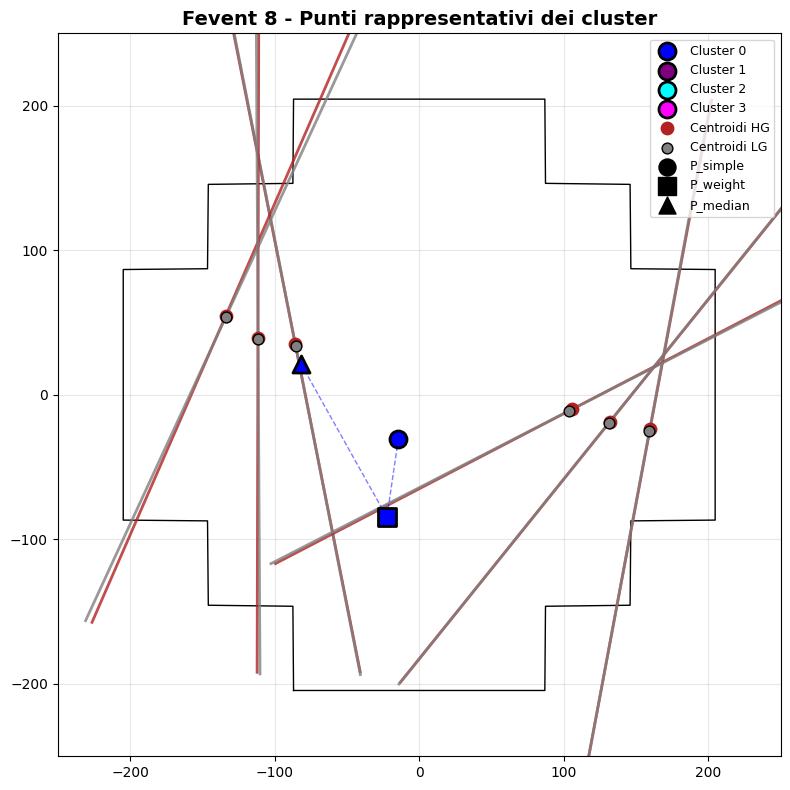

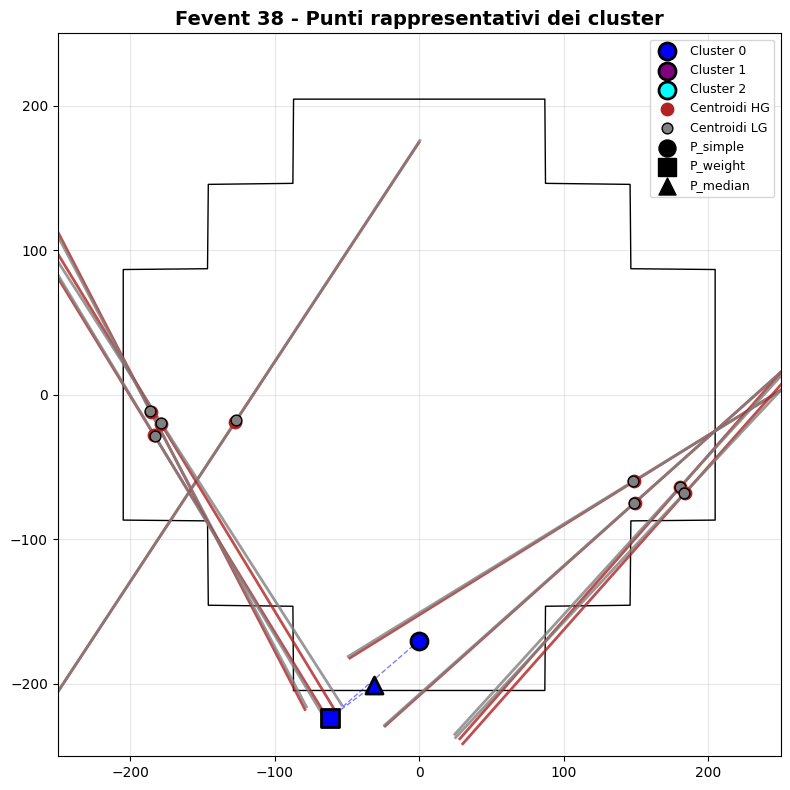

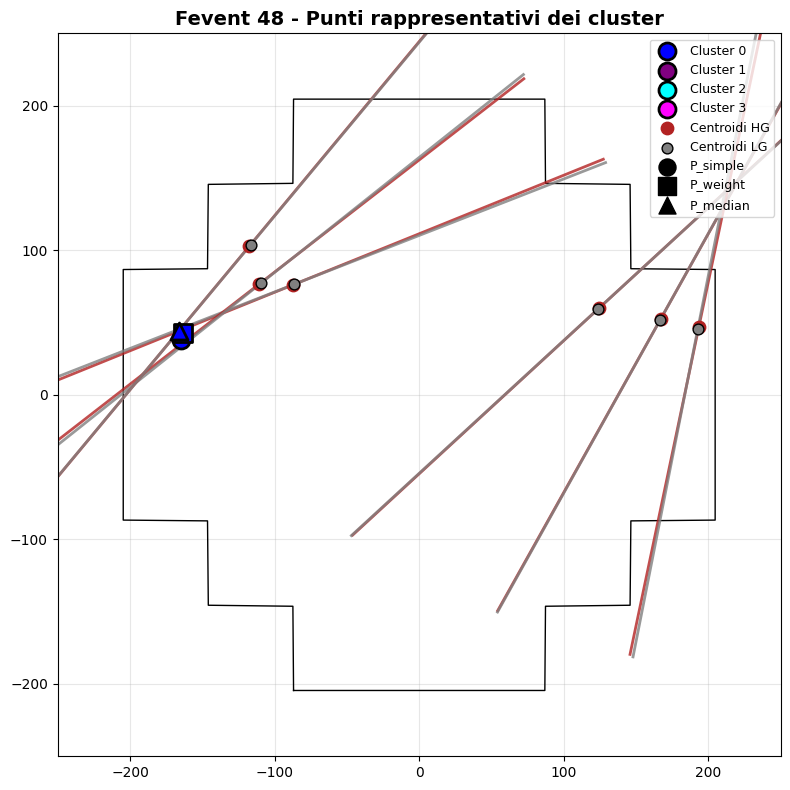

In [125]:
thr = 1e3

# Trova i fevent che hanno almeno una distanza > threshold
fevents_big_hg = df_dist_hg_f[df_dist_hg_f["d_weight"] > thr]["fevent"].unique()

print(f"Fevents con distanze HG > {thr}: {fevents_big_hg}")

# ==================== PLOT ====================
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.40 * diag

# Loop sui primi 3 fevents con distanze grandi
for fevent in fevents_big_hg[:3]:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # footprint camera
    ax.plot(xfp, yfp, 'k-', linewidth=1)

    # seleziona tutte le rette di questo fevent
    rette_evento = [r for r in results_f if r["fevent"] == fevent]

    for r in rette_evento:
        # HG
        p0 = r["HG"]["p0"]
        d  = r["HG"]["d"]
        ax.scatter(p0[0], p0[1], s=80, color="firebrick", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="firebrick", linewidth=2, alpha=0.8)

        # LG
        p0 = r["LG"]["p0"]
        d  = r["LG"]["d"]
        ax.scatter(p0[0], p0[1], s=60, color="grey", edgecolor="black", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="grey", linewidth=2, alpha=0.8)
    
    # TUTTI i punti P_simple, P_weight, P_median di ogni cluster
    df_fev_hg = df_dist_hg_f[df_dist_hg_f["fevent"] == fevent]
    
    colors_cluster = ['blue', 'purple', 'cyan', 'magenta']  # Colori per cluster diversi
    
    for idx, cluster_id in enumerate(df_fev_hg["cluster"].unique()):
        color = colors_cluster[idx % len(colors_cluster)]
        
        # Prendi la prima riga del cluster (tutti hanno gli stessi P_simple, P_weight, P_median)
        df_cluster = df_fev_hg[df_fev_hg["cluster"] == cluster_id].iloc[0]
        
        P_simple = df_cluster["P_simple"]
        P_weight = df_cluster["P_weight"]
        P_median = df_cluster["P_median"]
        
        # Plotta i 3 punti per questo cluster
        ax.scatter(P_simple[0], P_simple[1], s=150, color=color, marker='o', 
                  edgecolor='black', linewidth=2, zorder=10, 
                  label=f"Cluster {cluster_id}")
        ax.scatter(P_weight[0], P_weight[1], s=150, color=color, marker='s', 
                  edgecolor='black', linewidth=2, zorder=10)
        ax.scatter(P_median[0], P_median[1], s=150, color=color, marker='^', 
                  edgecolor='black', linewidth=2, zorder=10)
        
        # Collega i 3 punti con una linea per vedere quanto sono vicini
        ax.plot([P_simple[0], P_weight[0], P_median[0]], 
               [P_simple[1], P_weight[1], P_median[1]], 
               color=color, linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Fevent {fevent} - Punti rappresentativi dei cluster", 
                fontsize=14, fontweight='bold')
    
    # legends
    ax.scatter([], [], color='firebrick', s=80, label="Centroidi HG")
    ax.scatter([], [], color='grey', s=60, edgecolor='black', label="Centroidi LG")
    ax.scatter([], [], color='black', s=150, marker='o', edgecolor='black', label="P_simple")
    ax.scatter([], [], color='black', s=150, marker='s', edgecolor='black', label="P_weight")
    ax.scatter([], [], color='black', s=150, marker='^', edgecolor='black', label="P_median")
    
    # Aggiungi legenda per i cluster nella parte bassa
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc="upper right", fontsize=9)
    
    plt.tight_layout()
    plt.show()

Fevents con distanze HG > 0.1: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209]


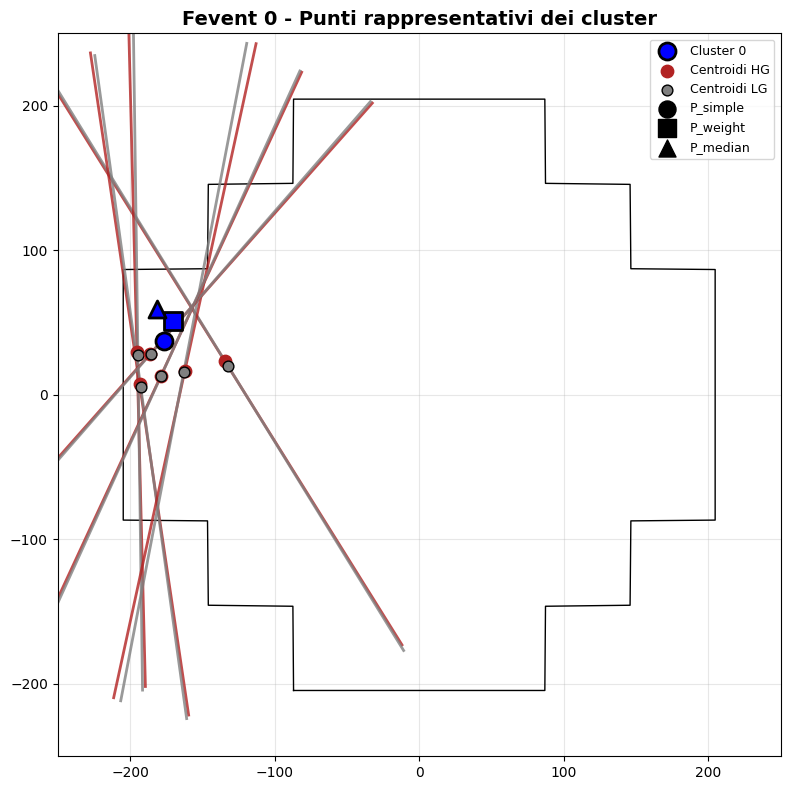

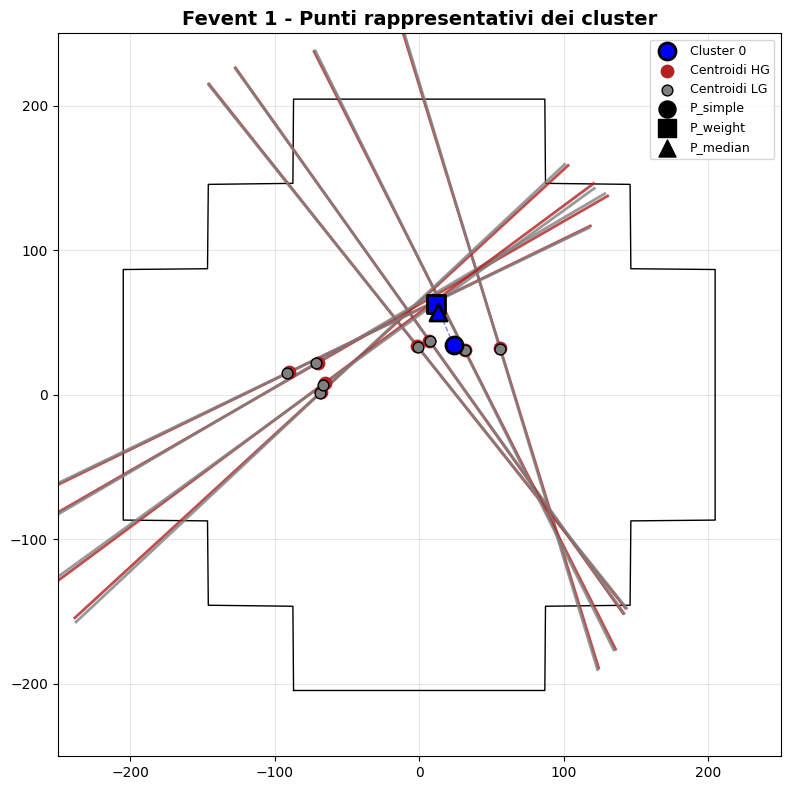

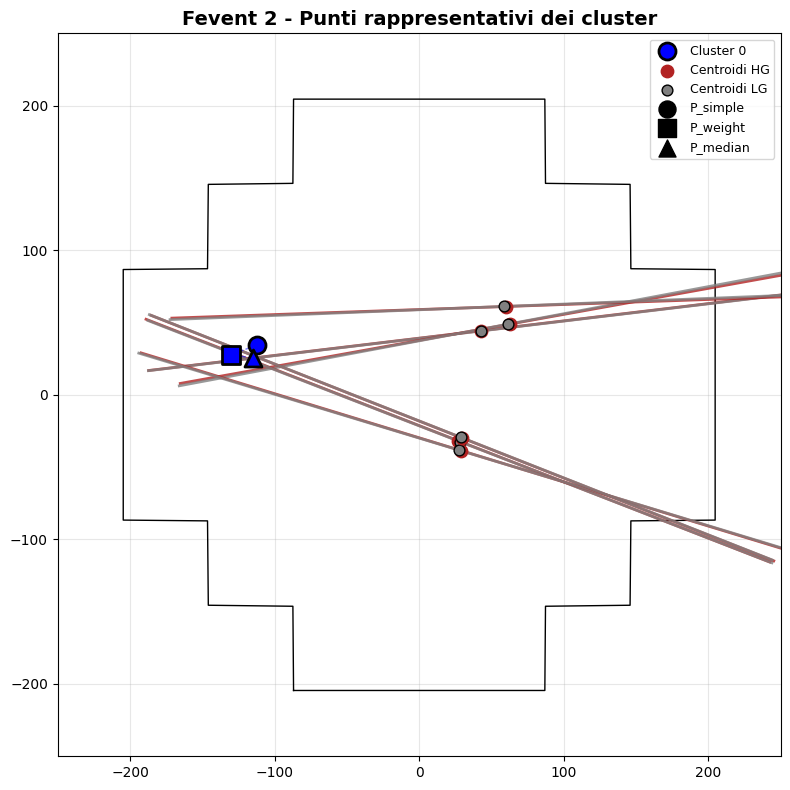

In [127]:
thr = 1e-1

# Trova i fevent che hanno almeno una distanza > threshold
fevents_big_hg = df_dist_hg_f[df_dist_hg_f["d_weight"] > thr]["fevent"].unique()

print(f"Fevents con distanze HG > {thr}: {fevents_big_hg}")

# ==================== PLOT ====================
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.40 * diag

# Loop sui primi 3 fevents con distanze grandi
for fevent in fevents_big_hg[:3]:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # footprint camera
    ax.plot(xfp, yfp, 'k-', linewidth=1)

    # seleziona tutte le rette di questo fevent
    rette_evento = [r for r in results_f if r["fevent"] == fevent]

    for r in rette_evento:
        # HG
        p0 = r["HG"]["p0"]
        d  = r["HG"]["d"]
        ax.scatter(p0[0], p0[1], s=80, color="firebrick", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="firebrick", linewidth=2, alpha=0.8)

        # LG
        p0 = r["LG"]["p0"]
        d  = r["LG"]["d"]
        ax.scatter(p0[0], p0[1], s=60, color="grey", edgecolor="black", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="grey", linewidth=2, alpha=0.8)
    
    # TUTTI i punti P_simple, P_weight, P_median di ogni cluster
    df_fev_hg = df_dist_hg_f[df_dist_hg_f["fevent"] == fevent]
    
    colors_cluster = ['blue', 'purple', 'cyan', 'magenta']  # Colori per cluster diversi
    
    for idx, cluster_id in enumerate(df_fev_hg["cluster"].unique()):
        color = colors_cluster[idx % len(colors_cluster)]
        
        # Prendi la prima riga del cluster (tutti hanno gli stessi P_simple, P_weight, P_median)
        df_cluster = df_fev_hg[df_fev_hg["cluster"] == cluster_id].iloc[0]
        
        P_simple = df_cluster["P_simple"]
        P_weight = df_cluster["P_weight"]
        P_median = df_cluster["P_median"]
        
        # Plotta i 3 punti per questo cluster
        ax.scatter(P_simple[0], P_simple[1], s=150, color=color, marker='o', 
                  edgecolor='black', linewidth=2, zorder=10, 
                  label=f"Cluster {cluster_id}")
        ax.scatter(P_weight[0], P_weight[1], s=150, color=color, marker='s', 
                  edgecolor='black', linewidth=2, zorder=10)
        ax.scatter(P_median[0], P_median[1], s=150, color=color, marker='^', 
                  edgecolor='black', linewidth=2, zorder=10)
        
        # Collega i 3 punti con una linea per vedere quanto sono vicini
        ax.plot([P_simple[0], P_weight[0], P_median[0]], 
               [P_simple[1], P_weight[1], P_median[1]], 
               color=color, linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Fevent {fevent} - Punti rappresentativi dei cluster", 
                fontsize=14, fontweight='bold')
    
    # legends
    ax.scatter([], [], color='firebrick', s=80, label="Centroidi HG")
    ax.scatter([], [], color='grey', s=60, edgecolor='black', label="Centroidi LG")
    ax.scatter([], [], color='black', s=150, marker='o', edgecolor='black', label="P_simple")
    ax.scatter([], [], color='black', s=150, marker='s', edgecolor='black', label="P_weight")
    ax.scatter([], [], color='black', s=150, marker='^', edgecolor='black', label="P_median")
    
    # Aggiungi legenda per i cluster nella parte bassa
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc="upper right", fontsize=9)
    
    plt.tight_layout()
    plt.show()

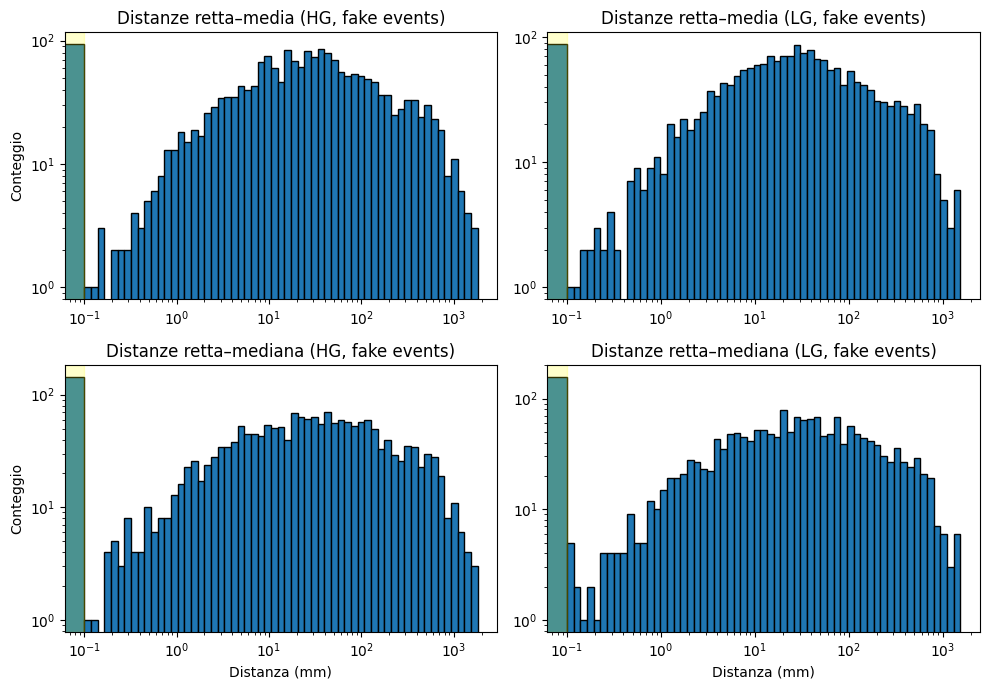

In [79]:
# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg_f   = df_dist_hg_f["d_weight"].values
d_median_hg_f = df_dist_hg_f["d_median"].values
d_mean_lg_f   = df_dist_lg_f["d_weight"].values
d_median_lg_f = df_dist_lg_f["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg_f   = d_mean_hg_f[np.isfinite(d_mean_hg_f) & (d_mean_hg_f > 0)]
d_median_hg_f = d_median_hg_f[np.isfinite(d_median_hg_f) & (d_median_hg_f > 0)]
d_mean_lg_f   = d_mean_lg_f[np.isfinite(d_mean_lg_f) & (d_mean_lg_f > 0)]
d_median_lg_f = d_median_lg_f[np.isfinite(d_median_lg_f) & (d_median_lg_f > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=60, zero_threshold=0.1):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg_f)
bins_median_hg = smart_bins(d_median_hg_f)
bins_mean_lg   = smart_bins(d_mean_lg_f)
bins_median_lg = smart_bins(d_median_lg_f)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg_f, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, fake events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg_f, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, fake events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg_f, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, fake events)")

axes[1,1].hist(d_median_lg_f, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, fake events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.axvspan(0, 0.1, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


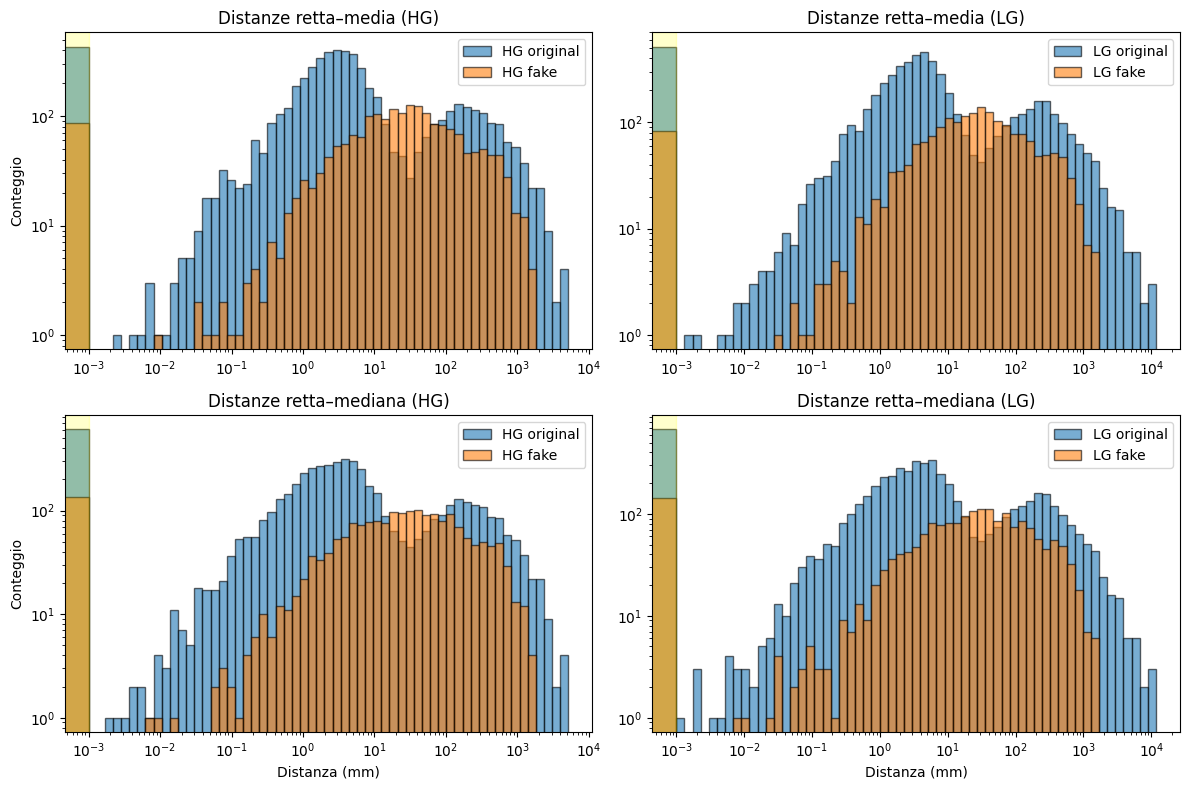

In [80]:


zero_threshold = 0.001
n_bins = 60

def smart_bins(data, n_bins=n_bins, zero_threshold=zero_threshold):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg   = df_dist_lg["d_weight"].values
d_median_lg = df_dist_lg["d_median"].values

d_mean_hg_f   = df_dist_hg_f["d_weight"].values
d_median_hg_f = df_dist_hg_f["d_median"].values
d_mean_lg_f   = df_dist_lg_f["d_weight"].values
d_median_lg_f = df_dist_lg_f["d_median"].values

# filtro valori validi (>0 e finiti)
datasets = [d_mean_hg, d_median_hg, d_mean_lg, d_median_lg,
            d_mean_hg_f, d_median_hg_f, d_mean_lg_f, d_median_lg_f]

datasets = [d[np.isfinite(d) & (d > 0)] for d in datasets]
d_mean_hg, d_median_hg, d_mean_lg, d_median_lg, \
d_mean_hg_f, d_median_hg_f, d_mean_lg_f, d_median_lg_f = datasets

# ===================== BINS COMUNI =====================
# Calcoliamo un bin comune per ogni tipo di distanza
bins_mean_hg   = smart_bins(np.concatenate([d_mean_hg, d_mean_hg_f]))
bins_median_hg = smart_bins(np.concatenate([d_median_hg, d_median_hg_f]))
bins_mean_lg   = smart_bins(np.concatenate([d_mean_lg, d_mean_lg_f]))
bins_median_lg = smart_bins(np.concatenate([d_median_lg, d_median_lg_f]))

# ===================== PLOT COMPARATIVO =====================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)

# -------------------- HG Mean --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black', alpha=0.6, label='HG original')
axes[0,0].hist(d_mean_hg_f, bins=bins_mean_hg, edgecolor='black', alpha=0.6, label='HG fake')
axes[0,0].set_title("Distanze retta–media (HG)")
axes[0,0].set_ylabel("Conteggio")
axes[0,0].legend()

# -------------------- HG Median --------------------
axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black', alpha=0.6, label='HG original')
axes[1,0].hist(d_median_hg_f, bins=bins_median_hg, edgecolor='black', alpha=0.6, label='HG fake')
axes[1,0].set_title("Distanze retta–mediana (HG)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")
axes[1,0].legend()

# -------------------- LG Mean --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black', alpha=0.6, label='LG original')
axes[0,1].hist(d_mean_lg_f, bins=bins_mean_lg, edgecolor='black', alpha=0.6, label='LG fake')
axes[0,1].set_title("Distanze retta–media (LG)")
axes[0,1].legend()

# -------------------- LG Median --------------------
axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black', alpha=0.6, label='LG original')
axes[1,1].hist(d_median_lg_f, bins=bins_median_lg, edgecolor='black', alpha=0.6, label='LG fake')
axes[1,1].set_title("Distanze retta–mediana (LG)")
axes[1,1].set_xlabel("Distanza (mm)")
axes[1,1].legend()

# scala log su entrambi gli assi + evidenzia bin ~0
for ax in axes.flat:
    ax.axvspan(0, zero_threshold, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()


In [14]:
print(df_dist_hg_f.columns)

Index(['fevent', 'event', 'mcrun', 'cluster', 'tel', 'P_simple', 'P_weight',
       'P_median', 'd_mean_simple', 'd_weight', 'd_median'],
      dtype='object')


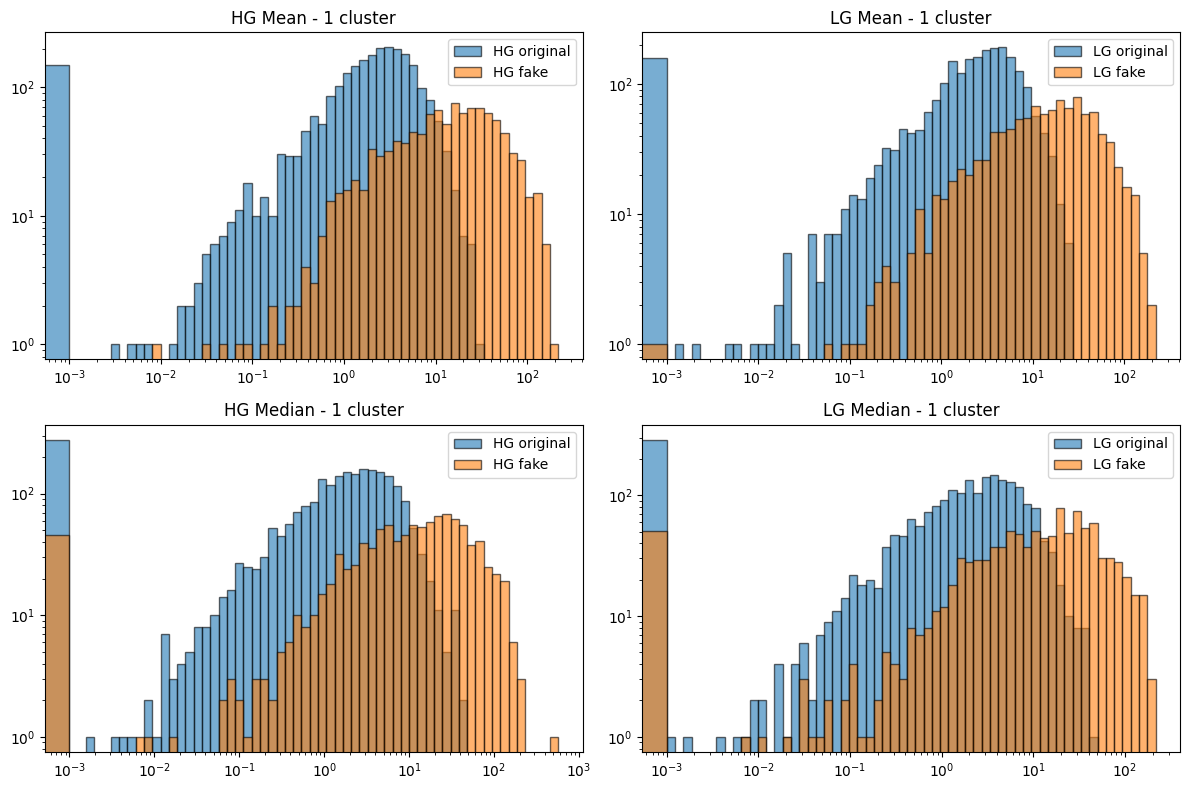

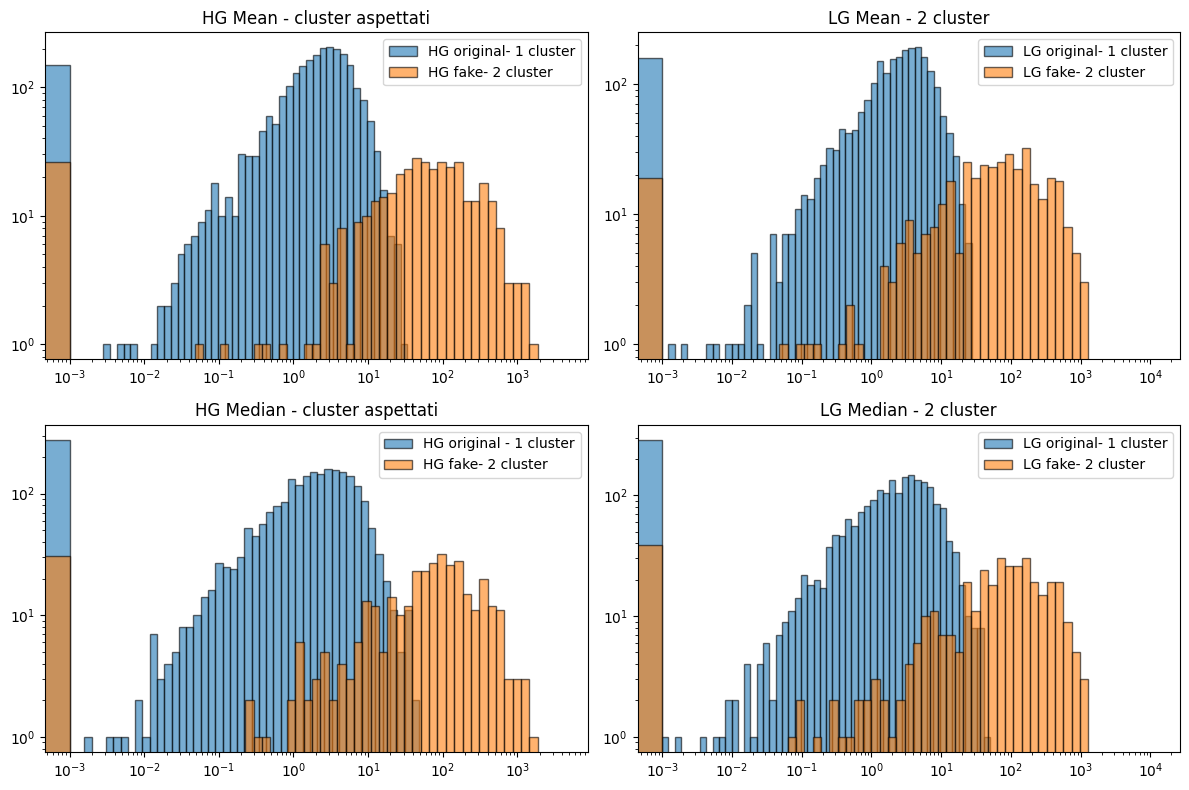

In [ ]:
zero_threshold = 0.001
n_bins = 60

# ===================== SELEZIONE EVENTI =====================
# -------------------- Eventi con 1 cluster --------------------
eventi_cluster_hg_1 = df_dist_hg.groupby(["revent"])["cluster"].nunique()
eventi_validi_hg_1 = eventi_cluster_hg_1[eventi_cluster_hg_1 == 1].index
df_sel_hg_1 = df_dist_hg.set_index(["revent"]).loc[eventi_validi_hg_1].reset_index()

eventi_cluster_lg_1 = df_dist_lg.groupby(["revent"])["cluster"].nunique()
eventi_validi_lg_1 = eventi_cluster_lg_1[eventi_cluster_lg_1 == 1].index
df_sel_lg_1 = df_dist_lg.set_index(["revent"]).loc[eventi_validi_lg_1].reset_index()

eventi_cluster_hg_f_1 = df_dist_hg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_hg_f_1 = eventi_cluster_hg_f_1[eventi_cluster_hg_f_1 == 1].index
df_sel_hg_f_1 = df_dist_hg_f.set_index(["fevent"]).loc[eventi_validi_hg_f_1].reset_index()

eventi_cluster_lg_f_1 = df_dist_lg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_lg_f_1 = eventi_cluster_lg_f_1[eventi_cluster_lg_f_1 == 1].index
df_sel_lg_f_1 = df_dist_lg_f.set_index(["fevent"]).loc[eventi_validi_lg_f_1].reset_index()


# -------------------- Eventi con 2 cluster --------------------
eventi_cluster_hg_2 = df_dist_hg.groupby(["revent"])["cluster"].nunique()
eventi_validi_hg_2 = eventi_cluster_hg_2[eventi_cluster_hg_2 == 2].index
df_sel_hg_2 = df_dist_hg.set_index(["revent"]).loc[eventi_validi_hg_2].reset_index()

eventi_cluster_lg_2 = df_dist_lg.groupby(["revent"])["cluster"].nunique()
eventi_validi_lg_2 = eventi_cluster_lg_2[eventi_cluster_lg_2 == 2].index
df_sel_lg_2 = df_dist_lg.set_index(["revent"]).loc[eventi_validi_lg_2].reset_index()

eventi_cluster_hg_f_2 = df_dist_hg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_hg_f_2 = eventi_cluster_hg_f_2[eventi_cluster_hg_f_2 == 2].index
df_sel_hg_f_2 = df_dist_hg_f.set_index(["fevent"]).loc[eventi_validi_hg_f_2].reset_index()

eventi_cluster_lg_f_2 = df_dist_lg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_lg_f_2 = eventi_cluster_lg_f_2[eventi_cluster_lg_f_2 == 2].index
df_sel_lg_f_2 = df_dist_lg_f.set_index(["fevent"]).loc[eventi_validi_lg_f_2].reset_index()


# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg_1   = df_sel_hg_1["d_weight"].values
d_median_hg_1 = df_sel_hg_1["d_median"].values
d_mean_lg_1   = df_sel_lg_1["d_weight"].values
d_median_lg_1 = df_sel_lg_1["d_median"].values
d_mean_hg_f_1   = df_sel_hg_f_1["d_weight"].values
d_median_hg_f_1 = df_sel_hg_f_1["d_median"].values
d_mean_lg_f_1   = df_sel_lg_f_1["d_weight"].values
d_median_lg_f_1 = df_sel_lg_f_1["d_median"].values

d_mean_hg_2   = df_sel_hg_2["d_weight"].values
d_median_hg_2 = df_sel_hg_2["d_median"].values
d_mean_lg_2   = df_sel_lg_2["d_weight"].values
d_median_lg_2 = df_sel_lg_2["d_median"].values
d_mean_hg_f_2   = df_sel_hg_f_2["d_weight"].values
d_median_hg_f_2 = df_sel_hg_f_2["d_median"].values
d_mean_lg_f_2   = df_sel_lg_f_2["d_weight"].values
d_median_lg_f_2 = df_sel_lg_f_2["d_median"].values

# filtro valori validi (>0 e finiti)
datasets_1 = [d_mean_hg_1, d_median_hg_1, d_mean_lg_1, d_median_lg_1,
              d_mean_hg_f_1, d_median_hg_f_1, d_mean_lg_f_1, d_median_lg_f_1]
datasets_1 = [d[np.isfinite(d) & (d > 0)] for d in datasets_1]
d_mean_hg_1, d_median_hg_1, d_mean_lg_1, d_median_lg_1, \
d_mean_hg_f_1, d_median_hg_f_1, d_mean_lg_f_1, d_median_lg_f_1 = datasets_1

datasets_2 = [d_mean_hg_2, d_median_hg_2, d_mean_lg_2, d_median_lg_2,
              d_mean_hg_f_2, d_median_hg_f_2, d_mean_lg_f_2, d_median_lg_f_2]
datasets_2 = [d[np.isfinite(d) & (d > 0)] for d in datasets_2]
d_mean_hg_2, d_median_hg_2, d_mean_lg_2, d_median_lg_2, \
d_mean_hg_f_2, d_median_hg_f_2, d_mean_lg_f_2, d_median_lg_f_2 = datasets_2

# ===================== BINS COMUNI =====================
bins_mean_hg_1   = smart_bins(np.concatenate([d_mean_hg_1, d_mean_hg_f_1]))
bins_median_hg_1 = smart_bins(np.concatenate([d_median_hg_1, d_median_hg_f_1]))
bins_mean_lg_1   = smart_bins(np.concatenate([d_mean_lg_1, d_mean_lg_f_1]))
bins_median_lg_1 = smart_bins(np.concatenate([d_median_lg_1, d_median_lg_f_1]))

bins_mean_hg_2   = smart_bins(np.concatenate([d_mean_hg_2, d_mean_hg_f_2]))
bins_median_hg_2 = smart_bins(np.concatenate([d_median_hg_2, d_median_hg_f_2]))
bins_mean_lg_2   = smart_bins(np.concatenate([d_mean_lg_2, d_mean_lg_f_2]))
bins_median_lg_2 = smart_bins(np.concatenate([d_median_lg_2, d_median_lg_f_2]))

# ===================== PLOT =====================
# Plot per eventi con 1 cluster
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(d_mean_hg_1, bins=bins_mean_hg_1, edgecolor='black', alpha=0.6, label='HG original')
axes[0,0].hist(d_mean_hg_f_1, bins=bins_mean_hg_1, edgecolor='black', alpha=0.6, label='HG fake')
axes[0,0].set_title("HG Mean - 1 cluster")
axes[0,0].legend()
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_median_hg_1, bins=bins_median_hg_1, edgecolor='black', alpha=0.6, label='HG original')
axes[1,0].hist(d_median_hg_f_1, bins=bins_median_hg_1, edgecolor='black', alpha=0.6, label='HG fake')
axes[1,0].set_title("HG Median - 1 cluster")
axes[1,0].legend()
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

axes[0,1].hist(d_mean_lg_1, bins=bins_mean_lg_1, edgecolor='black', alpha=0.6, label='LG original')
axes[0,1].hist(d_mean_lg_f_1, bins=bins_mean_lg_1, edgecolor='black', alpha=0.6, label='LG fake')
axes[0,1].set_title("LG Mean - 1 cluster")
axes[0,1].legend()
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_median_lg_1, bins=bins_median_lg_1, edgecolor='black', alpha=0.6, label='LG original')
axes[1,1].hist(d_median_lg_f_1, bins=bins_median_lg_1, edgecolor='black', alpha=0.6, label='LG fake')
axes[1,1].set_title("LG Median - 1 cluster")
axes[1,1].legend()
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()

# Plot per eventi con 2 cluster
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(d_mean_hg_1, bins=bins_mean_hg_1, edgecolor='black', alpha=0.6, label='HG original- 1 cluster')
axes[0,0].hist(d_mean_hg_f_2, bins=bins_mean_hg_2, edgecolor='black', alpha=0.6, label='HG fake- 2 cluster')
axes[0,0].set_title("HG Mean - cluster aspettati")
axes[0,0].legend()
axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log")

axes[1,0].hist(d_median_hg_1, bins=bins_median_hg_1, edgecolor='black', alpha=0.6, label='HG original - 1 cluster')
axes[1,0].hist(d_median_hg_f_2, bins=bins_median_hg_2, edgecolor='black', alpha=0.6, label='HG fake- 2 cluster')
axes[1,0].set_title("HG Median - cluster aspettati")
axes[1,0].legend()
axes[1,0].set_xscale("log")
axes[1,0].set_yscale("log")

axes[0,1].hist(d_mean_lg_1, bins=bins_mean_lg_1, edgecolor='black', alpha=0.6, label='LG original- 1 cluster')
axes[0,1].hist(d_mean_lg_f_2, bins=bins_mean_lg_2, edgecolor='black', alpha=0.6, label='LG fake- 2 cluster')
axes[0,1].set_title("LG Mean - cluster aspettati")
axes[0,1].legend()
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")

axes[1,1].hist(d_median_lg_1, bins=bins_median_lg_1, edgecolor='black', alpha=0.6, label='LG original- 1 cluster')
axes[1,1].hist(d_median_lg_f_2, bins=bins_median_lg_2, edgecolor='black', alpha=0.6, label='LG fake- 2 cluster')
axes[1,1].set_title("LG Median - cluster aspettati")
axes[1,1].legend()
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()


In [ ]:
min_samples = 1
eps_values = np.linspace(1, 800, 20)
print("=== REAL ===")
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1 = 100 * n_1cl / n_evt if n_evt > 0 else 0
    p2 = 100 * n_2cl / n_evt if n_evt > 0 else 0

    print(f"eps={eps:.1f}: 1 cluster = {p1:.1f}%, 2 cluster = {p2:.1f}%")
print("\n=== FAKE ===")
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for fevent, df_evt in df_int_hg_f.groupby("fevent"):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1 = 100 * n_1cl / n_evt if n_evt > 0 else 0
    p2 = 100 * n_2cl / n_evt if n_evt > 0 else 0

    print(f"eps={eps:.1f}: 1 cluster = {p1:.1f}%, 2 cluster = {p2:.1f}%")

=== REAL ===
eps=50.0: 1 cluster = 29.1%, 2 cluster = 21.7%
eps=350.0: 1 cluster = 70.2%, 2 cluster = 23.9%
eps=750.0: 1 cluster = 83.9%, 2 cluster = 14.6%

=== FAKE ===
eps=50.0: 1 cluster = 22.3%, 2 cluster = 14.7%
eps=350.0: 1 cluster = 60.4%, 2 cluster = 11.7%
eps=750.0: 1 cluster = 71.1%, 2 cluster = 13.2%


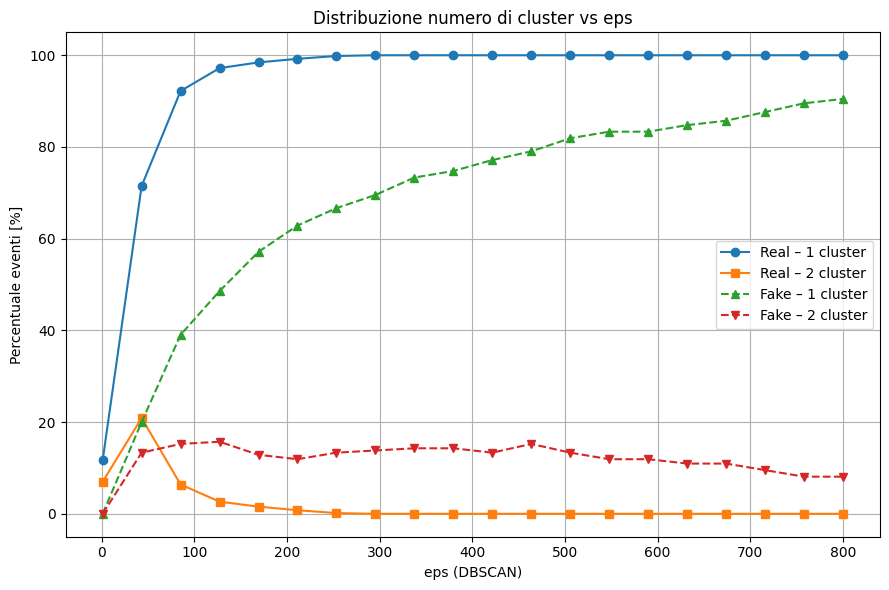

In [82]:
min_samples = 1
eps_values = np.linspace(1, 800, 20)

# ===================== LISTE RISULTATI =====================
p1_real, p2_real = [], []
p1_fake, p2_fake = [], []

# ===================== REAL =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1_real.append(100 * n_1cl / n_evt if n_evt > 0 else 0)
    p2_real.append(100 * n_2cl / n_evt if n_evt > 0 else 0)

# ===================== FAKE =====================
for eps in eps_values:

    n_evt = 0
    n_1cl = 0
    n_2cl = 0

    for fevent, df_evt in df_int_hg_f.groupby("fevent"):

        P = np.vstack(df_evt["P"].values)
        if len(P) == 0:
            continue

        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(P)
        n_clusters = len(set(labels) - {-1})

        if n_clusters == 1:
            n_1cl += 1
        elif n_clusters == 2:
            n_2cl += 1

        n_evt += 1

    p1_fake.append(100 * n_1cl / n_evt if n_evt > 0 else 0)
    p2_fake.append(100 * n_2cl / n_evt if n_evt > 0 else 0)

# ===================== PLOT =====================
plt.figure(figsize=(9,6))

plt.plot(eps_values, p1_real, marker='o', label="Real – 1 cluster")
plt.plot(eps_values, p2_real, marker='s', label="Real – 2 cluster")

plt.plot(eps_values, p1_fake, marker='^', linestyle='--', label="Fake – 1 cluster")
plt.plot(eps_values, p2_fake, marker='v', linestyle='--', label="Fake – 2 cluster")

plt.xlabel("eps (DBSCAN)")
plt.ylabel("Percentuale eventi [%]")
plt.title("Distribuzione numero di cluster vs eps")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


KeyError: "None of [Index(['event_line', 'mcrun_line'], dtype='object')] are in the [columns]"

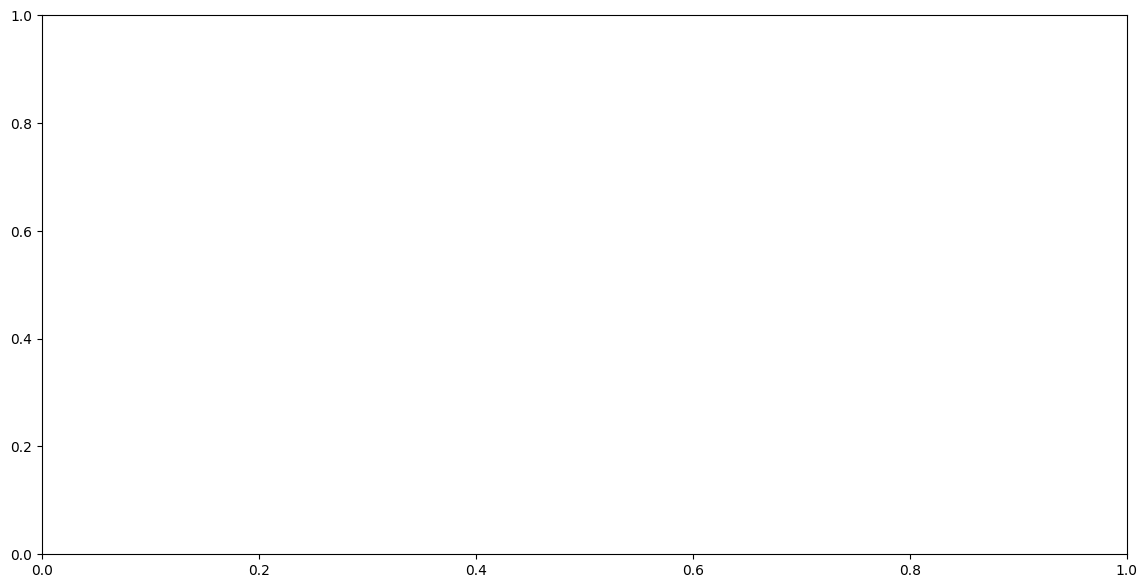

In [16]:
# ==================== PLOT UNICO ====================

fig, ax = plt.subplots(figsize=(14, 7))

# Liste per accumulare tutte le distanze
all_dist_same = []
all_dist_other = []

fevents = df_dist_hg_f["fevent"].unique()

for fev in fevents:
    df_fev = df_dist_hg_f[df_dist_hg_f["fevent"] == fev]
    
    # Trova le 2 coppie (event, mcrun) in questo fevent
    pairs = df_fev[["event_line", "mcrun_line"]].drop_duplicates().values
    print(f"\nfevent {fev}: {pairs}")
    
    # Per ogni cluster
    for cluster_id in df_fev["cluster"].unique():
        df_cluster = df_fev[df_fev["cluster"] == cluster_id]
        
        # Trova quale (event,mcrun) appartiene a questo cluster
        avg_dists = []
        for evt, mc in pairs:
            mask = (df_cluster["event_line"] == evt) & (df_cluster["mcrun_line"] == mc)
            dists = df_cluster.loc[mask, "d_weight"].values
            dists = dists[np.isfinite(dists) & (dists > 0)]
            avg_dists.append(np.median(dists) if len(dists) > 0 else np.inf)
        
        cluster_pair_idx = np.argmin(avg_dists)
        cluster_evt, cluster_mc = pairs[cluster_pair_idx]
        
        print(f"  Cluster {cluster_id} → evt={cluster_evt}, mc={cluster_mc}")
        
        # Separa SAME vs OTHER
        mask_same = (df_cluster["event_line"] == cluster_evt) & (df_cluster["mcrun_line"] == cluster_mc)
        mask_other = ~mask_same
        
        dist_same = df_cluster.loc[mask_same, "d_weight"].values
        dist_other = df_cluster.loc[mask_other, "d_weight"].values
        
        dist_same = dist_same[np.isfinite(dist_same) & (dist_same > 0)]
        dist_other = dist_other[np.isfinite(dist_other) & (dist_other > 0)]
        
        # Accumula
        all_dist_same.extend(dist_same)
        all_dist_other.extend(dist_other)

# Converti in array
all_dist_same = np.array(all_dist_same)
all_dist_other = np.array(all_dist_other)

print(f"\nTotale SAME: {len(all_dist_same)}")
print(f"Totale OTHER: {len(all_dist_other)}")

# Plot unico
if len(all_dist_same) > 0 or len(all_dist_other) > 0:
    max_dist = max(
        all_dist_same.max() if len(all_dist_same) > 0 else 1,
        all_dist_other.max() if len(all_dist_other) > 0 else 1
    )
    bins = np.logspace(-3, np.log10(max_dist), 60)
    
    if len(all_dist_same) > 0:
        ax.hist(all_dist_same, bins=bins, alpha=0.6,
                label=f'Cluster → sue rette (n={len(all_dist_same)})',
                color='blue', edgecolor='black', linewidth=0.5)
    
    if len(all_dist_other) > 0:
        ax.hist(all_dist_other, bins=bins, alpha=0.6,
                label=f'Cluster → altre rette (n={len(all_dist_other)})',
                color='red', edgecolor='black', linewidth=0.5)

ax.axvline(1e-3, color='yellow', linestyle='--', linewidth=2, alpha=0.7, label='~0 threshold')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Distanza (mm)", fontsize=13)
ax.set_ylabel("Conteggio", fontsize=13)
ax.set_title("Diagnostica Clustering - HG (tutti i fevents)", fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [ ]:
threshold =0  # distanza massima per considerare la retta parte del cluster/evento

# ======================= HG =======================
dist_hg_tagged = []

for (event, mcrun), df_evt in df_dist_hg.groupby(["event","mcrun"]):
    # ciclo sui cluster già calcolati
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        # centroide del cluster
        P_mean = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]  # distanza già calcolata dal cluster
            tag = "this_event" if dm <= threshold else "other_event"

            dist_hg_tagged.append({
                "revent":row["revent"],
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_median": P_median.copy()
            })

df_dist_hg_tagged = pd.DataFrame(dist_hg_tagged)


# ======================= LG =======================
dist_lg_tagged = []

for (event, mcrun), df_evt in df_dist_lg.groupby(["event","mcrun"]):
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        P_median = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]
            tag = "this_event" if dm <= threshold else "other_event"

            dist_lg_tagged.append({
                "revent":row["revent"],
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_mean": P_mean.copy()
            })

df_dist_lg_tagged = pd.DataFrame(dist_lg_tagged)


In [ ]:
##=============================0 FAKE EVENT ===========================================
dist_hg_tagged = []
for fevent, df_evt in df_dist_hg_f.groupby("fevent"):
    # ciclo sui cluster già calcolati
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        # centroide del cluster
        P_mean = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]  # distanza già calcolata dal cluster
            tag = "this_event" if dm <= threshold else "other_event"

            dist_hg_tagged.append({
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_median": P_median.copy()
            })

df_dist_hg_tagged_f = pd.DataFrame(dist_hg_tagged)


# ======================= LG =======================
dist_lg_tagged = []

for fevent, df_evt in df_dist_lg_f.groupby("fevent"):
    for cluster_id, df_cl in df_evt.groupby("cluster"):
        P_median = df_cl["P_median"].values[0] if "P_median" in df_cl else np.mean(np.vstack(df_cl["P_median"].values), axis=0)

        for idx, row in df_cl.iterrows():
            dm = row["d_weight"]
            tag = "this_event" if dm <= threshold else "other_event"

            dist_lg_tagged.append({
                "event": row["event"],
                "mcrun": row["mcrun"],
                "cluster": row["cluster"],
                "tel": row["tel"],
                "d_weight": row["d_weight"],
                "d_median": row["d_median"],
                "tag": tag,
                "P_mean": P_mean.copy()
            })

df_dist_lg_tagged_f = pd.DataFrame(dist_lg_tagged)

In [ ]:
'''
def build_tagged_df(df_dist, threshold, dist_col="d_weight"):
    """
    Tagging per-retta corretto.

    - per ogni revent:
        - ogni retta sceglie la distanza MINIMA tra tutti i cluster
        - se min_dist <= threshold → retta appartiene all’evento
    - tutte le rette buone dello stesso revent hanno lo STESSO tag
    - tag = 0 → retta non associata a nessun evento
    """
    df = df_dist.copy()
    tagged_rows = []
    next_tag = 1

    for revent, df_evt in df.groupby("revent"):

        # distanza minima per ogni telescopio
        min_dist = df_evt.groupby("tel")[dist_col].min()

        # telescopi buoni
        good_tel = min_dist[min_dist <= threshold].index

        if len(good_tel) > 0:
            tag = next_tag
            next_tag += 1
        else:
            tag = 0

        for _, row in df_evt.iterrows():
            out = row.to_dict()
            if row["tel"] in good_tel:
                out["tag"] = tag
            else:
                out["tag"] = 0
            tagged_rows.append(out)

    return pd.DataFrame(tagged_rows)
'''

In [20]:
def build_tagged_df(df_dist, threshold, dist_col="d_weight"):
    """
    Tagging per-retta corretto.

    - per ogni revent / fevent:
        - ogni retta sceglie la distanza MINIMA tra tutti i cluster
        - se min_dist <= threshold → retta appartiene all’evento
    - tutte le rette buone dello stesso evento hanno lo STESSO tag
    - tag = 0 → retta non associata a nessun evento
    """

    df = df_dist.copy()

    # colonna unificata per eventi
    if "revent" in df.columns:
        df["event_id"] = df["revent"]
    elif "fevent" in df.columns:
        df["event_id"] = df["fevent"]
    else:
        df["event_id"] = 0  # fallback se non esiste nessuna colonna

    tagged_rows = []
    next_tag = 1

    for event_id, df_evt in df.groupby("event_id"):

        # distanza minima per ogni telescopio
        min_dist = df_evt.groupby("tel")[dist_col].min()

        # telescopi buoni
        good_tel = min_dist[min_dist <= threshold].index

        if len(good_tel) > 0:
            tag = next_tag
            next_tag += 1
        else:
            tag = 0

        for _, row in df_evt.iterrows():
            out = row.to_dict()
            if row["tel"] in good_tel:
                out["tag"] = tag
            else:
                out["tag"] = 0
            tagged_rows.append(out)

    return pd.DataFrame(tagged_rows)

In [21]:
######## tagged sequenziale
def build_tagged_df_sequential(df_dist, threshold, dist_col="d_weight"):
    """
    Tagging per-retta corretto, versione sequenziale.

    - per ogni revent / fevent:
        - per ogni telescopio, controlla una per una le distanze
        - se trova almeno una distanza <= threshold → retta appartiene all'evento
        - altrimenti → tag = 0
    - tutte le rette buone dello stesso evento hanno lo STESSO tag
    """
    df = df_dist.copy()

    # colonna unificata per eventi
    if "revent" in df.columns:
        df["event_id"] = df["revent"]
    elif "fevent" in df.columns:
        df["event_id"] = df["fevent"]
    else:
        df["event_id"] = 0  # fallback se non esiste nessuna colonna

    tagged_rows = []
    next_tag = 1

    for event_id, df_evt in df.groupby("event_id"):

        good_tel = []

        # scansiona telescopi uno per uno
        for tel, df_tel in df_evt.groupby("tel"):
            # scansiona le distanze finché trovi una sotto soglia
            if any(df_tel[dist_col] <= threshold):
                good_tel.append(tel)

        # assegna tag
        if len(good_tel) > 0:
            tag = next_tag
            next_tag += 1
        else:
            tag = 0

        # costruisci le righe taggate
        for _, row in df_evt.iterrows():
            out = row.to_dict()
            out["tag"] = tag if row["tel"] in good_tel else 0
            tagged_rows.append(out)

    return pd.DataFrame(tagged_rows)


In [22]:
#===========================prova=============================
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


'''
def evaluate_tagging_accuracy(df, tag_col="tag"):
    """
    Valuta quanto bene il clustering riconosce gli eventi reali.
    Considera solo i cluster/eventi riconosciuti (tag > 0).
    """

    # Assicuriamoci che i tag siano numerici
    df[tag_col] = df[tag_col].astype(int)

    # Lista degli eventi MC
    events_mc = df.groupby(["revent", "event", "mcrun"])
    N_true = len(events_mc)

    # Controllo coerenza dei tag per ciascun evento MC
    split_check = events_mc[tag_col].nunique().reset_index(name="n_tag")

    # Considera solo eventi con almeno un tag > 0
    max_tag_per_event = events_mc[tag_col].max().values
    split_check = split_check[max_tag_per_event > 0]

    # N_good = eventi MC con tag coerente (tutti i telescopi hanno stesso tag)
    N_good = (split_check["n_tag"] == 1).sum()

    # N_reco = numero di cluster distinti riconosciuti (tag > 0)
    N_reco = df[df[tag_col] > 0][tag_col].nunique()

    # Accuracy (considera tutti i telescopi)
    y_true = [1] * len(df)
    y_pred = df[tag_col].apply(lambda x: 1 if x > 0 else 0).values
    acc = accuracy_score(y_true, y_pred)

    # Frazioni
    frac_true = N_good / N_true if N_true > 0 else 0
    frac_reco = N_good / N_reco if N_reco > 0 else 0

    result = {
        "accuracy": acc,
        "N_true": N_true,
        "N_good": N_good,
        "N_reco": N_reco,
        "frac_true": frac_true,
        "frac_reco": frac_reco
    }

    return result
'''
def evaluate_tagging_accuracy(df, tag_col="tag"):
    """
    Valuta quanto bene il clustering riconosce gli eventi reali.
    Considera solo i cluster/eventi riconosciuti (tag > 0).
    Funziona sia se c'è 'revent' sia 'fevent'.
    """

    # Assicuriamoci che i tag siano numerici (tag non convertibili diventano 0)
    df[tag_col] = pd.to_numeric(df[tag_col], errors='coerce').fillna(0).astype(int)

    # Scegliamo la colonna dell'evento
    if "revent" in df.columns:
        event_col = "revent"
    elif "fevent" in df.columns:
        event_col = "fevent"
    else:
        event_col = None

    # Lista degli eventi MC
    if event_col:
        events_mc = df.groupby([event_col, "event", "mcrun"])
    else:
        events_mc = df.groupby(["event", "mcrun"])
        
    N_true = len(events_mc)

    # Controllo coerenza dei tag per ciascun evento MC
    split_check = events_mc[tag_col].nunique().reset_index(name="n_tag")

    # Considera solo eventi con almeno un tag > 0
    max_tag_per_event = events_mc[tag_col].max().reset_index(name="max_tag")["max_tag"]
    split_check = split_check[max_tag_per_event > 0]

    # N_good = eventi MC con tag coerente (tutti i telescopi hanno lo stesso tag)
    N_good = (split_check["n_tag"] == 1).sum()

    # N_reco = numero di cluster/eventi ricostruiti (tag > 0)
    N_reco = df[df[tag_col] > 0][tag_col].nunique()

    # Accuracy (considera tutti i telescopi)
    import numpy as np
    y_true = np.ones(len(df))
    y_pred = (df[tag_col] > 0).astype(int).values
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_true, y_pred)

    # Frazioni
    frac_true = N_good / N_true if N_true > 0 else 0
    frac_reco = N_good / N_reco if N_reco > 0 else 0

    result = {
        "accuracy": acc,
        "N_true": N_true,
        "N_good": N_good,
        "N_reco": N_reco,
        "frac_true": frac_true,
        "frac_reco": frac_reco
    }

    return result

df_prova= build_tagged_df(df_dist_hg_f,1000)
result = evaluate_tagging_accuracy(df_prova)

print("Accuracy (tutti i telescopi):      ", result["accuracy"])
print("Eventi MC totali (N_true):         ", result["N_true"])
print("Eventi MC riconosciuti correttamente (N_good):", result["N_good"])
print("Eventi ricostruiti (N_reco):       ", result["N_reco"])
print("Frazione corretti / totali (N_good/N_true): ", result["frac_true"])
print("Frazione corretti / ricostruiti (N_good/N_reco): ", result["frac_reco"])


Accuracy (tutti i telescopi):       1.0
Eventi MC totali (N_true):          394
Eventi MC riconosciuti correttamente (N_good): 394
Eventi ricostruiti (N_reco):        197
Frazione corretti / totali (N_good/N_true):  1.0
Frazione corretti / ricostruiti (N_good/N_reco):  2.0


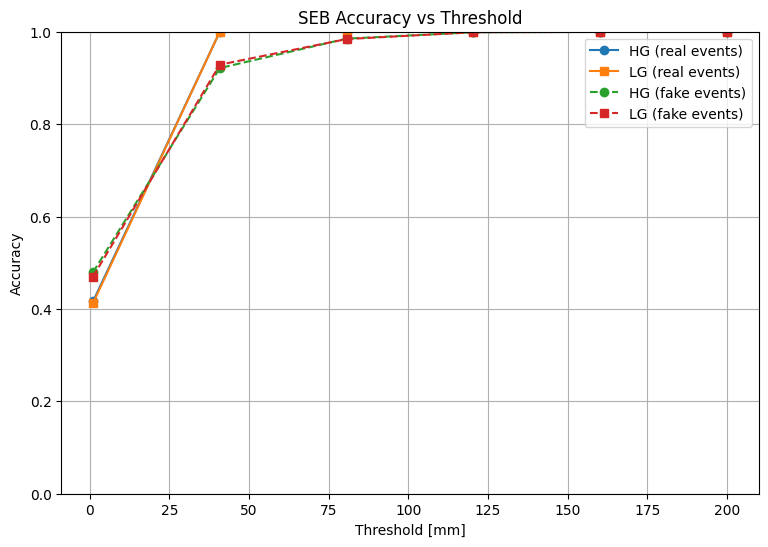

In [23]:
threshold_values = np.linspace(1, 200, 6)

# Array dove salvare le metriche
acc_hg_real, acc_lg_real = [], []
acc_hg_fake, acc_lg_fake = [], []

# ==================== LOOP PER CALCOLARE LE METRICHE ====================
for thr in threshold_values:

    # HG real
    df_tagged = build_tagged_df(df_dist_hg, thr, dist_col="d_weight")
    result = evaluate_tagging_accuracy(df_tagged)
    acc_hg_real.append(result["accuracy"])

    # LG real
    df_tagged = build_tagged_df(df_dist_lg, thr, dist_col="d_weight")
    result = evaluate_tagging_accuracy(df_tagged)
    acc_lg_real.append(result["accuracy"])

    # HG fake
    df_tagged = build_tagged_df(df_dist_hg_f, thr, dist_col="d_weight")
    result = evaluate_tagging_accuracy(df_tagged)
    acc_hg_fake.append(result["accuracy"])

    # LG fake
    df_tagged = build_tagged_df(df_dist_lg_f, thr, dist_col="d_weight")
    result = evaluate_tagging_accuracy(df_tagged)
    acc_lg_fake.append(result["accuracy"])

# ==================== PLOT ACCURACY ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, acc_hg_real, marker='o', label="HG (real events)")
plt.plot(threshold_values, acc_lg_real, marker='s', label="LG (real events)")
plt.plot(threshold_values, acc_hg_fake, marker='o', linestyle='--', label="HG (fake events)")
plt.plot(threshold_values, acc_lg_fake, marker='s', linestyle='--', label="LG (fake events)")

plt.xlabel("Threshold [mm]")
plt.ylabel("Accuracy")
plt.title("SEB Accuracy vs Threshold")
plt.grid(True)
plt.legend()
plt.ylim(0,1)
plt.show()

In [26]:
'''
# ==================== Threshold da testare ====================
threshold_values = np.linspace(1, 500, 6)

# ==================== Liste per salvare le frazioni ====================
frac_true_hg_real, frac_reco_hg_real = [], []
frac_true_lg_real, frac_reco_lg_real = [], []
frac_true_hg_fake, frac_reco_hg_fake = [], []
frac_true_lg_fake, frac_reco_lg_fake = [], []

# ==================== Loop sui threshold ====================
for thr in threshold_values:

    # ---------- HG real ----------
    df_tagged = build_tagged_df(df_dist_hg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_hg_real.append(res["frac_true"])
    frac_reco_hg_real.append(res["frac_reco"])

    # ---------- LG real ----------
    df_tagged = build_tagged_df(df_dist_lg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_lg_real.append(res["frac_true"])
    frac_reco_lg_real.append(res["frac_reco"])

    # ---------- HG fake ----------
    df_tagged = build_tagged_df(df_dist_hg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_hg_fake.append(res["frac_true"])
    frac_reco_hg_fake.append(res["frac_reco"])

    # ---------- LG fake ----------
    df_tagged = build_tagged_df(df_dist_lg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_lg_fake.append(res["frac_true"])
    frac_reco_lg_fake.append(res["frac_reco"])

# ==================== PLOT N_good / N_true ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, frac_true_hg_real, marker='o', label="HG Real")
plt.plot(threshold_values, frac_true_lg_real, marker='s', label="LG Real")
plt.plot(threshold_values, frac_true_hg_fake, marker='^', label="HG Fake")
plt.plot(threshold_values, frac_true_lg_fake, marker='v', label="LG Fake")
plt.xlabel("Threshold [mm]")
plt.ylabel("N_good / N_true")
plt.title("Frazione Eventi Riconosciuti / Totali (N_good/N_true)")
plt.grid(True)
plt.legend()
#plt.ylim(0,1)
plt.show()

# ==================== PLOT N_good / N_reco ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, frac_reco_hg_real, marker='o', linestyle='-', label="HG Real")
plt.plot(threshold_values, frac_reco_lg_real, marker='s', linestyle='-', label="LG Real")
plt.plot(threshold_values, frac_reco_hg_fake, marker='^', linestyle='--', label="HG Fake")
plt.plot(threshold_values, frac_reco_lg_fake, marker='v', linestyle='--', label="LG Fake")
plt.xlabel("Threshold [mm]")
plt.ylabel("N_good / N_reco")
plt.title("Frazione Eventi Riconosciuti / Ricostruiti (N_good/N_reco)")
plt.grid(True)
plt.legend()
#plt.ylim(0,1)
plt.show()
'''

'\n# ==================== Threshold da testare ====================\nthreshold_values = np.linspace(1, 500, 6)\n\n# ==================== Liste per salvare le frazioni ====================\nfrac_true_hg_real, frac_reco_hg_real = [], []\nfrac_true_lg_real, frac_reco_lg_real = [], []\nfrac_true_hg_fake, frac_reco_hg_fake = [], []\nfrac_true_lg_fake, frac_reco_lg_fake = [], []\n\n# ==================== Loop sui threshold ====================\nfor thr in threshold_values:\n\n    # ---------- HG real ----------\n    df_tagged = build_tagged_df(df_dist_hg, thr, dist_col="d_weight")\n    res = evaluate_tagging_accuracy(df_tagged)\n    frac_true_hg_real.append(res["frac_true"])\n    frac_reco_hg_real.append(res["frac_reco"])\n\n    # ---------- LG real ----------\n    df_tagged = build_tagged_df(df_dist_lg, thr, dist_col="d_weight")\n    res = evaluate_tagging_accuracy(df_tagged)\n    frac_true_lg_real.append(res["frac_true"])\n    frac_reco_lg_real.append(res["frac_reco"])\n\n    # ---------- 

In [33]:
#prova 
def build_tagged_df_sequential(df_dist, threshold, dist_col="d_weight"):
    """
    Tagging per cluster:
    - Per ogni cluster, scansiona sequenzialmente le rette
    - Se distanza <= threshold → assegna il tag del cluster
    - Altrimenti → tag = 0
    
    Ogni cluster ha un tag univoco progressivo.
    """
    df = df_dist.copy()
    
    # Colonna unificata per eventi
    if "revent" in df.columns:
        df["event_id"] = df["revent"]
    elif "fevent" in df.columns:
        df["event_id"] = df["fevent"]
    else:
        df["event_id"] = 0
    
    tagged_rows = []
    next_tag = 1
    
    # Per ogni evento (fevent/revent)
    for event_id, df_evt in df.groupby("event_id"):
        
        # Per ogni cluster in questo evento
        for cluster_id, df_cluster in df_evt.groupby("cluster"):
            
            # Questo cluster riceve un tag univoco
            tag = next_tag
            next_tag += 1
            
            # Scansiona sequenzialmente ogni retta (ogni tel)
            for tel, df_tel in df_cluster.groupby("tel"):
                
                # Prendi la distanza di questa retta da questo cluster
                # (dovrebbe essere una sola riga per tel in questo cluster)
                distances = df_tel[dist_col].values
                
                # Se ALMENO UNA distanza è <= threshold → tag buono
                if any(distances <= threshold):
                    retta_tag = tag
                else:
                    retta_tag = 0
                
                # Salva tutte le righe di questo telescopio con il tag
                for _, row in df_tel.iterrows():
                    out = row.to_dict()
                    out["tag"] = retta_tag
                    tagged_rows.append(out)
    
    return pd.DataFrame(tagged_rows)


# ========== TEST ==========
# df_tagged = build_tagged_df_sequential(df_dist_hg_f, threshold=10.0, dist_col="d_weight")

# print("\nStatistiche tagging:")
# print(f"Tag 0 (rette scartate): {(df_tagged['tag'] == 0).sum()}")
# print(f"Tag > 0 (rette buone): {(df_tagged['tag'] > 0).sum()}")
# print(f"\nNumero di cluster identificati: {df_tagged[df_tagged['tag'] > 0]['tag'].nunique()}")

# # Vedi distribuzione tag
# print("\nConteggio rette per tag:")
# print(df_tagged['tag'].value_counts().sort_index())
def evaluate_tagging_accuracy(df, tag_col="tag"):
    """
    Valuta quanto bene il tagging riconosce gli eventi reali.
    Gestisce sia 'event'/'mcrun' che 'event_line'/'mcrun_line'
    """
    
    df = df.copy()
    df[tag_col] = pd.to_numeric(df[tag_col], errors='coerce').fillna(0).astype(int)
    
    # Identifica colonna evento
    if "revent" in df.columns:
        event_col = "revent"
    elif "fevent" in df.columns:
        event_col = "fevent"
    else:
        print("⚠️ Nessuna colonna revent/fevent trovata!")
        return None
    
    # Identifica colonne event e mcrun (possono avere _line o no)
    if "event_line" in df.columns and "mcrun_line" in df.columns:
        evt_col = "event_line"
        mc_col = "mcrun_line"
    elif "event" in df.columns and "mcrun" in df.columns:
        evt_col = "event"
        mc_col = "mcrun"
    else:
        print("⚠️ Nessuna colonna event/mcrun trovata!")
        print(f"Colonne disponibili: {df.columns.tolist()}")
        return None
    
    # ---------- N_true: conta eventi reali unici ----------
    true_events = df.groupby([event_col, evt_col, mc_col]).size().reset_index(name="count")
    N_true = len(true_events)
    
    print(f"\n{'='*70}")
    print(f"VALUTAZIONE TAGGING")
    print(f"{'='*70}")
    print(f"Eventi reali totali ({evt_col}, {mc_col}): {N_true}")
    
    # ---------- Analisi per cluster (tag > 0) ----------
    df_reco = df[df[tag_col] > 0].copy()
    
    if len(df_reco) == 0:
        print("⚠️ Nessun cluster riconosciuto (tutti tag = 0)!")
        return {
            "N_true": N_true,
            "N_reco": 0,
            "N_good": 0,
            "N_mixed": 0,
            "N_complete": 0,
            "N_split": 0,
            "N_not_reco": N_true,
            "purity": 0,
            "completeness": 0,
            "accuracy": 0
        }
    
    N_reco = df_reco[tag_col].nunique()
    print(f"Cluster riconosciuti (tag > 0): {N_reco}")
    
    # ---------- Analisi purezza cluster ----------
    N_good = 0
    N_mixed = 0
    
    cluster_stats = []
    
    for tag, df_tag in df_reco.groupby(tag_col):
        # Per questo cluster, quanti (event, mcrun) diversi ci sono?
        unique_events = df_tag[[evt_col, mc_col]].drop_duplicates()
        n_events = len(unique_events)
        
        if n_events == 1:
            N_good += 1
            purity = "GOOD"
        else:
            N_mixed += 1
            purity = "MIXED"
        
        cluster_stats.append({
            "tag": tag,
            "n_events": n_events,
            "n_rette": len(df_tag),
            "purity": purity,
            "events": list(unique_events.itertuples(index=False, name=None))
        })
    
    print(f"\nCluster GOOD (un solo evento): {N_good}")
    print(f"Cluster MIXED (più eventi mescolati): {N_mixed}")
    
    # ---------- Analisi completezza eventi ----------
    N_split = 0
    
    event_coverage = []
    
    for (evt_id, evt, mc), df_evt in df.groupby([event_col, evt_col, mc_col]):
        # Quanti tag ha questo evento?
        tags = df_evt[df_evt[tag_col] > 0][tag_col].unique()
        n_tags = len(tags)
        n_rette_totali = len(df_evt)
        n_rette_riconosciute = len(df_evt[df_evt[tag_col] > 0])
        
        if n_tags == 0:
            status = "NOT_RECO"
        elif n_tags == 1:
            status = "COMPLETE"
        else:
            status = "SPLIT"
            N_split += 1
        
        event_coverage.append({
            "event_id": evt_id,
            "event": evt,
            "mcrun": mc,
            "n_tags": n_tags,
            "tags": list(tags),
            "n_rette_totali": n_rette_totali,
            "n_rette_reco": n_rette_riconosciute,
            "status": status
        })
    
    N_complete = sum(1 for e in event_coverage if e["status"] == "COMPLETE")
    N_not_reco = sum(1 for e in event_coverage if e["status"] == "NOT_RECO")
    
    print(f"\nEventi COMPLETE (tutte le rette in 1 cluster): {N_complete}")
    print(f"Eventi SPLIT (rette divise in più cluster): {N_split}")
    print(f"Eventi NOT_RECO (nessuna retta riconosciuta): {N_not_reco}")
    
    # ---------- Metriche finali ----------
    purity = N_good / N_reco if N_reco > 0 else 0
    completeness = N_complete / N_true if N_true > 0 else 0
    total_rette = len(df)
    correct_rette = len(df_reco)
    accuracy = correct_rette / total_rette if total_rette > 0 else 0
    
    print(f"\n{'='*70}")
    print(f"METRICHE")
    print(f"{'='*70}")
    print(f"Purity (cluster puri):        {purity:.2%} ({N_good}/{N_reco})")
    print(f"Completeness (eventi interi): {completeness:.2%} ({N_complete}/{N_true})")
    print(f"Accuracy (rette taggate):     {accuracy:.2%} ({correct_rette}/{total_rette})")
    
    return {
        "N_true": N_true,
        "N_reco": N_reco,
        "N_good": N_good,
        "N_mixed": N_mixed,
        "N_complete": N_complete,
        "N_split": N_split,
        "N_not_reco": N_not_reco,
        "purity": purity,
        "completeness": completeness,
        "accuracy": accuracy,
        "cluster_stats": cluster_stats,
        "event_coverage": event_coverage
    }

# ========== UTILIZZO ==========
# results = evaluate_tagging_accuracy(df_tagged, tag_col="tag")

# # Per vedere dettagli
# import pandas as pd
# print("\nDettaglio cluster:")
# print(pd.DataFrame(results["cluster_stats"]))

# print("\nDettaglio eventi:")
# print(pd.DataFrame(results["event_coverage"]))

In [34]:
# ==================== Threshold da testare ====================
threshold_values = np.linspace(1, 500, 20)  # Ho aumentato i punti per vedere meglio

# ==================== Liste per salvare le metriche ====================
purity_hg_real, completeness_hg_real = [], []
purity_lg_real, completeness_lg_real = [], []
purity_hg_fake, completeness_hg_fake = [], []
purity_lg_fake, completeness_lg_fake = [], []

# Numero di eventi riconosciuti
n_reco_hg_real, n_reco_lg_real = [], []
n_reco_hg_fake, n_reco_lg_fake = [], []

# ==================== Loop sui threshold ====================
print("Testing thresholds...")
for i, thr in enumerate(threshold_values):
    print(f"\n{'='*70}")
    print(f"Threshold {i+1}/{len(threshold_values)}: {thr:.1f} mm")
    print(f"{'='*70}")

    # ---------- HG real ----------
    print("\n[HG REAL]")
    df_tagged = build_tagged_df_sequential(df_dist_hg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    purity_hg_real.append(res["purity"])
    completeness_hg_real.append(res["completeness"])
    n_reco_hg_real.append(res["N_reco"])

    # ---------- LG real ----------
    print("\n[LG REAL]")
    df_tagged = build_tagged_df_sequential(df_dist_lg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    purity_lg_real.append(res["purity"])
    completeness_lg_real.append(res["completeness"])
    n_reco_lg_real.append(res["N_reco"])

    # ---------- HG fake ----------
    print("\n[HG FAKE]")
    df_tagged = build_tagged_df_sequential(df_dist_hg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    purity_hg_fake.append(res["purity"])
    completeness_hg_fake.append(res["completeness"])
    n_reco_hg_fake.append(res["N_reco"])

    # ---------- LG fake ----------
    print("\n[LG FAKE]")
    df_tagged = build_tagged_df_sequential(df_dist_lg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    purity_lg_fake.append(res["purity"])
    completeness_lg_fake.append(res["completeness"])
    n_reco_lg_fake.append(res["N_reco"])

# ==================== PLOT 1: PURITY (cluster puri) ====================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(threshold_values, purity_hg_real, marker='o', linestyle='-', linewidth=2, 
        label="HG Real", color='blue')
ax.plot(threshold_values, purity_lg_real, marker='s', linestyle='-', linewidth=2, 
        label="LG Real", color='cyan')
ax.plot(threshold_values, purity_hg_fake, marker='^', linestyle='--', linewidth=2, 
        label="HG Fake", color='red')
ax.plot(threshold_values, purity_lg_fake, marker='v', linestyle='--', linewidth=2, 
        label="LG Fake", color='orange')

ax.set_xlabel("Threshold [mm]", fontsize=13)
ax.set_ylabel("Purity (N_good / N_reco)", fontsize=13)
ax.set_title("Purezza Cluster: frazione di cluster con UN SOLO evento", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# ==================== PLOT 2: COMPLETENESS (eventi completi) ====================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(threshold_values, completeness_hg_real, marker='o', linestyle='-', linewidth=2, 
        label="HG Real", color='blue')
ax.plot(threshold_values, completeness_lg_real, marker='s', linestyle='-', linewidth=2, 
        label="LG Real", color='cyan')
ax.plot(threshold_values, completeness_hg_fake, marker='^', linestyle='--', linewidth=2, 
        label="HG Fake", color='red')
ax.plot(threshold_values, completeness_lg_fake, marker='v', linestyle='--', linewidth=2, 
        label="LG Fake", color='orange')

ax.set_xlabel("Threshold [mm]", fontsize=13)
ax.set_ylabel("Completeness (N_complete / N_true)", fontsize=13)
ax.set_title("Completezza: frazione di eventi COMPLETAMENTE ricostruiti in 1 cluster", 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# ==================== PLOT 3: Numero cluster riconosciuti ====================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(threshold_values, n_reco_hg_real, marker='o', linestyle='-', linewidth=2, 
        label="HG Real", color='blue')
ax.plot(threshold_values, n_reco_lg_real, marker='s', linestyle='-', linewidth=2, 
        label="LG Real", color='cyan')
ax.plot(threshold_values, n_reco_hg_fake, marker='^', linestyle='--', linewidth=2, 
        label="HG Fake", color='red')
ax.plot(threshold_values, n_reco_lg_fake, marker='v', linestyle='--', linewidth=2, 
        label="LG Fake", color='orange')

ax.set_xlabel("Threshold [mm]", fontsize=13)
ax.set_ylabel("N_reco (numero cluster)", fontsize=13)
ax.set_title("Numero di cluster riconosciuti (tag > 0)", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==================== PLOT 4: Confronto Purity vs Completeness ====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Real events
ax1.plot(threshold_values, purity_hg_real, marker='o', linestyle='-', linewidth=2, 
         label="Purity HG", color='blue')
ax1.plot(threshold_values, completeness_hg_real, marker='o', linestyle='--', linewidth=2, 
         label="Completeness HG", color='blue', alpha=0.6)
ax1.plot(threshold_values, purity_lg_real, marker='s', linestyle='-', linewidth=2, 
         label="Purity LG", color='cyan')
ax1.plot(threshold_values, completeness_lg_real, marker='s', linestyle='--', linewidth=2, 
         label="Completeness LG", color='cyan', alpha=0.6)

ax1.set_xlabel("Threshold [mm]", fontsize=12)
ax1.set_ylabel("Frazione", fontsize=12)
ax1.set_title("Eventi REALI", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_ylim([0, 1.05])

# Fake events
ax2.plot(threshold_values, purity_hg_fake, marker='^', linestyle='-', linewidth=2, 
         label="Purity HG", color='red')
ax2.plot(threshold_values, completeness_hg_fake, marker='^', linestyle='--', linewidth=2, 
         label="Completeness HG", color='red', alpha=0.6)
ax2.plot(threshold_values, purity_lg_fake, marker='v', linestyle='-', linewidth=2, 
         label="Purity LG", color='orange')
ax2.plot(threshold_values, completeness_lg_fake, marker='v', linestyle='--', linewidth=2, 
         label="Completeness LG", color='orange', alpha=0.6)

ax2.set_xlabel("Threshold [mm]", fontsize=12)
ax2.set_ylabel("Frazione", fontsize=12)
ax2.set_title("Eventi FAKE", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

Testing thresholds...

Threshold 1/20: 1.0 mm

[HG REAL]

VALUTAZIONE TAGGING
Eventi reali totali (event, mcrun): 691
Cluster riconosciuti (tag > 0): 780

Cluster GOOD (un solo evento): 780
Cluster MIXED (più eventi mescolati): 0

Eventi COMPLETE (tutte le rette in 1 cluster): 408
Eventi SPLIT (rette divise in più cluster): 164
Eventi NOT_RECO (nessuna retta riconosciuta): 119

METRICHE
Purity (cluster puri):        100.00% (780/780)
Completeness (eventi interi): 59.04% (408/691)
Accuracy (rette taggate):     26.23% (1552/5917)

[LG REAL]

VALUTAZIONE TAGGING
Eventi reali totali (event, mcrun): 692
Cluster riconosciuti (tag > 0): 803

Cluster GOOD (un solo evento): 803
Cluster MIXED (più eventi mescolati): 0

Eventi COMPLETE (tutte le rette in 1 cluster): 375
Eventi SPLIT (rette divise in più cluster): 190
Eventi NOT_RECO (nessuna retta riconosciuta): 127

METRICHE
Purity (cluster puri):        100.00% (803/803)
Completeness (eventi interi): 54.19% (375/692)
Accuracy (rette taggate):  

KeyboardInterrupt: 

In [30]:
# ==================== Threshold da testare ====================
threshold_values = np.linspace(1, 500, 6)

# ==================== Liste per salvare le frazioni ====================
frac_true_hg_real, frac_reco_hg_real = [], []
frac_true_lg_real, frac_reco_lg_real = [], []
frac_true_hg_fake, frac_reco_hg_fake = [], []
frac_true_lg_fake, frac_reco_lg_fake = [], []

# ==================== Loop sui threshold ====================
for thr in threshold_values:

    # ---------- HG real ----------
    df_tagged = build_tagged_df_sequential(df_dist_hg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_hg_real.append(res["frac_true"])
    frac_reco_hg_real.append(res["frac_reco"])

    # ---------- LG real ----------
    df_tagged = build_tagged_df_sequential(df_dist_lg, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_lg_real.append(res["frac_true"])
    frac_reco_lg_real.append(res["frac_reco"])

    # ---------- HG fake ----------
    df_tagged = build_tagged_df_sequential(df_dist_hg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_hg_fake.append(res["frac_true"])
    frac_reco_hg_fake.append(res["frac_reco"])

    # ---------- LG fake ----------
    df_tagged = build_tagged_df_sequential(df_dist_lg_f, thr, dist_col="d_weight")
    res = evaluate_tagging_accuracy(df_tagged)
    frac_true_lg_fake.append(res["frac_true"])
    frac_reco_lg_fake.append(res["frac_reco"])

# ==================== PLOT N_good / N_true ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, frac_true_hg_real, marker='o', label="HG Real")
plt.plot(threshold_values, frac_true_lg_real, marker='s', label="LG Real")
plt.plot(threshold_values, frac_true_hg_fake, marker='^', label="HG Fake")
plt.plot(threshold_values, frac_true_lg_fake, marker='v', label="LG Fake")
plt.xlabel("Threshold [mm]")
plt.ylabel("N_good / N_true")
plt.title("Frazione Eventi Riconosciuti / Totali (N_good/N_true)")
plt.grid(True)
plt.legend()
plt.show()

# ==================== PLOT N_good / N_reco ====================
plt.figure(figsize=(9,6))
plt.plot(threshold_values, frac_reco_hg_real, marker='o', linestyle='-', label="HG Real")
plt.plot(threshold_values, frac_reco_lg_real, marker='s', linestyle='-', label="LG Real")
plt.plot(threshold_values, frac_reco_hg_fake, marker='^', linestyle='--', label="HG Fake")
plt.plot(threshold_values, frac_reco_lg_fake, marker='v', linestyle='--', label="LG Fake")
plt.xlabel("Threshold [mm]")
plt.ylabel("N_good / N_reco")
plt.title("Frazione Eventi Riconosciuti / Ricostruiti (N_good/N_reco)")
plt.grid(True)
plt.legend()
plt.show()


KeyError: 'event_line'